### This notebook is for starting to analyse correlations between the MIDAS (historical Met Office) data and the PV_Live data.
Steps:
1. Replot a GSP from the bottom of 03 and identify nearby met office instruments (that are available at the time)
2. Pull PV_Live data from that day (already done in 03 notebook)
3. Pull MIDAS data from that day
4. Do a simple correl with closest instrument
    - should probably control for capacity, perhaps by dividing output by nominal capacity (given by PV_Live)
5. Try more advanced models with multiple instruments, based explicitly or implicitly on proximity

In [215]:
# from 03 notebook:

from pathlib import Path
import time

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

API_BASE_URL = "https://api.pvlive.uk/pvlive/api/v4"
CAPACITY_FIELD = "capacity_mwp"
# CAPACITY_FIELD = "installedcapacity_mwp"

REFERENCE_DATA_PATH = Path("../data/outputs/reference_data")
GSP_PATH = REFERENCE_DATA_PATH / "gsp_regions_with_colour_and_ghi_coverage.geojson"
OUTPUT_GEOJSON = REFERENCE_DATA_PATH / "gsp_regions_with_pvlive_capacity.geojson"
OUTPUT_CSV = REFERENCE_DATA_PATH / "gsp_regions_with_pvlive_capacity.csv"

# gsp_regions = gpd.read_file(GSP_PATH) # this uses the colour and GHI coverage geojson... i don't think i want to use this for now
gsp_regions = gpd.read_file(OUTPUT_GEOJSON) # this uses pvlive capacity

print(f"Loaded {len(gsp_regions)} GSP regions from {OUTPUT_GEOJSON}")

Loaded 362 GSP regions from ../data/outputs/reference_data/gsp_regions_with_pvlive_capacity.geojson


### Step 1. Replot a GSP from the bottom of 03 and identify nearby met office instruments (that are available at the time)

In [216]:
gsp_regions

,fid,GSPs,GSPGroup,SSEP17Zone,DSCPs,InGroup_,CDCA_I030,colour_index,colour_hex,ghi_instrument_count,has_ghi_instrument,gsp_id,gsp_name,datetime_gmt,capacity_mwp,geometry
0,1,LEGA_1,_D,7,NaN,Y,=GSP_LEGA_1,1,#377eb8,2,True,182.0,LEGA_1,2026-09-24 15:00:00+00:00,230.333,"MULTIPOLYGON (((-3.67528 52.3655, -3.67033 52...."
1,2,THSO_P,_P,1,NaN,Y,=GSP_THSO_P,1,#377eb8,1,True,288.0,THSO_P,2026-09-24 15:00:00+00:00,5.545,"MULTIPOLYGON (((-3.0732 58.73774, -3.07412 58...."
2,3,BRIM_1,_C,17,[+]BRIM_C,N,=II_BRIM_C,2,#4daf4a,0,False,40.0,BRIM_1,2026-09-24 15:00:00+00:00,40.393,"MULTIPOLYGON (((0.12638 51.59359, 0.12145 51.5..."
3,4,EERH,_N,4,NaN,Y,=GSP_EERH,0,#e41a1c,0,False,104.0,EERH,2026-09-24 15:00:00+00:00,12.054,"MULTIPOLYGON (((-4.1545 55.84639, -4.15447 55...."
4,5,AXMI1,_L,15,NaN,Y,=GSP_AXMI1,0,#e41a1c,0,False,13.0,AXMI1,2026-09-24 15:00:00+00:00,122.085,"MULTIPOLYGON (((-2.69894 50.68317, -2.69628 50..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,358,GREN_1,_A,11,[+]GREN_A,N,=II_GREN_A,0,#e41a1c,0,False,135.0,GREN_1,2026-09-24 15:00:00+00:00,402.401,"MULTIPOLYGON (((-0.50698 52.16285, -0.50383 52..."
358,359,TEMP_3,_M,8,NaN,Y,=GSP_TEMP_3,0,#e41a1c,0,False,286.0,TEMP_3,2026-09-24 15:00:00+00:00,0.702,"MULTIPOLYGON (((-1.30253 53.41214, -1.31115 53..."
359,360,ACTL_C,_C,17,NaN,Y,=GSP_ACTL_C,3,#f1c40f,0,False,318.0,ACTL_C,2026-09-24 15:00:00+00:00,2.093,"MULTIPOLYGON (((-0.21623 51.52806, -0.21621 51..."
360,361,NORM_1|SALL1,_A,12,NaN,Y|Y,=GSP_NORM_1+GSP_SALL1,1,#377eb8,0,False,214.0,NORM_1|SALL1,2026-09-24 15:00:00+00:00,447.511,"MULTIPOLYGON (((0.93345 52.97977, 0.93916 52.9..."


^ contains GSPs, gsp_id, gsp_name, capacity_mwp, and geometry

In [217]:
gsp_regions[
    ['gsp_id', 'gsp_name', 'capacity_mwp', 'geometry']
].head()

,gsp_id,gsp_name,capacity_mwp,geometry
0,182.0,LEGA_1,230.333,"MULTIPOLYGON (((-3.67528 52.3655, -3.67033 52...."
1,288.0,THSO_P,5.545,"MULTIPOLYGON (((-3.0732 58.73774, -3.07412 58...."
2,40.0,BRIM_1,40.393,"MULTIPOLYGON (((0.12638 51.59359, 0.12145 51.5..."
3,104.0,EERH,12.054,"MULTIPOLYGON (((-4.1545 55.84639, -4.15447 55...."
4,13.0,AXMI1,122.085,"MULTIPOLYGON (((-2.69894 50.68317, -2.69628 50..."


In [218]:
type(gsp_regions)

geopandas.geodataframe.GeoDataFrame

In [219]:
selected_region = gsp_regions[
    gsp_regions['gsp_id'] == 1
].copy()

In [220]:
selected_region

,fid,GSPs,GSPGroup,SSEP17Zone,DSCPs,InGroup_,CDCA_I030,colour_index,colour_hex,ghi_instrument_count,has_ghi_instrument,gsp_id,gsp_name,datetime_gmt,capacity_mwp,geometry
194,195,ABHA1,_L,15,NaN,Y,=GSP_ABHA1,2,#4daf4a,0,False,1.0,ABHA1,2026-09-24 15:00:00+00:00,229.129,"MULTIPOLYGON (((-3.41281 50.60831, -3.42287 50..."


/var/folders/hr/8b35c81n5gs9czlq47x9dtk00000gp/T/ipykernel_1113/518098226.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  selected_region['centre'] = selected_region.geometry.centroid


Text(200.0901165831339, 0.5, 'Latitude')

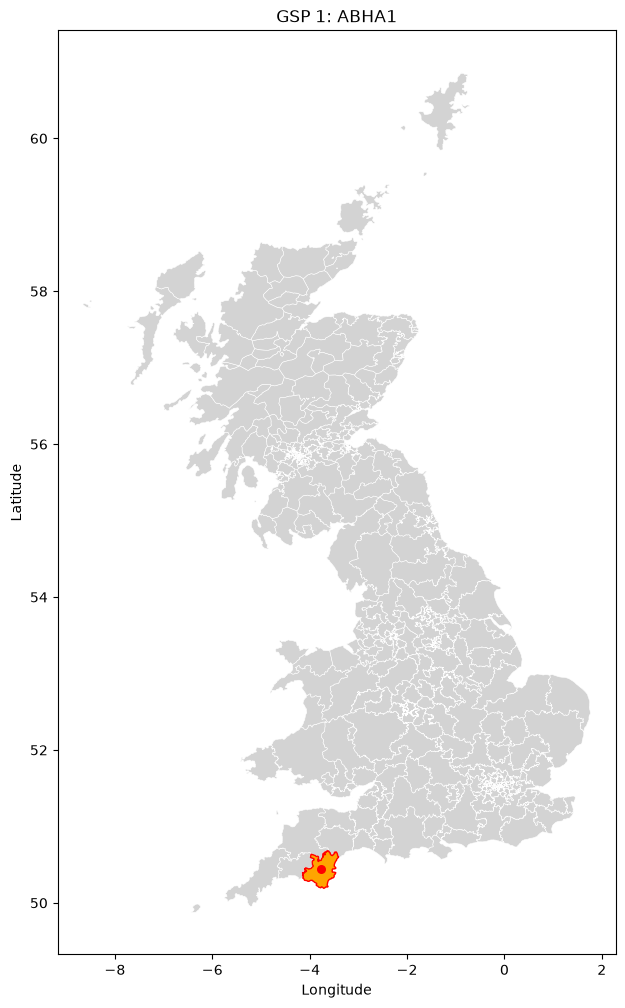

In [221]:
# want to get to this:

fig, ax = plt.subplots(figsize=(10,12))

gsp_regions.plot(
    ax=ax,
    facecolor='lightgrey',
    edgecolor='white',
    linewidth=0.4
)

selected_region.plot(
    ax=ax,
    facecolor='orange',
    edgecolor='red',
    linewidth=1
)

selected_region['centre'] = selected_region.geometry.centroid

selected_region['centre'].plot(
    ax=ax,
    color='red',
    markersize=30
)

ax.set_title('GSP 1: ABHA1')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [222]:
gsp_regions.head()

,fid,GSPs,GSPGroup,SSEP17Zone,DSCPs,InGroup_,CDCA_I030,colour_index,colour_hex,ghi_instrument_count,has_ghi_instrument,gsp_id,gsp_name,datetime_gmt,capacity_mwp,geometry
0,1,LEGA_1,_D,7,NaN,Y,=GSP_LEGA_1,1,#377eb8,2,True,182.0,LEGA_1,2026-09-24 15:00:00+00:00,230.333,"MULTIPOLYGON (((-3.67528 52.3655, -3.67033 52...."
1,2,THSO_P,_P,1,NaN,Y,=GSP_THSO_P,1,#377eb8,1,True,288.0,THSO_P,2026-09-24 15:00:00+00:00,5.545,"MULTIPOLYGON (((-3.0732 58.73774, -3.07412 58...."
2,3,BRIM_1,_C,17,[+]BRIM_C,N,=II_BRIM_C,2,#4daf4a,0,False,40.0,BRIM_1,2026-09-24 15:00:00+00:00,40.393,"MULTIPOLYGON (((0.12638 51.59359, 0.12145 51.5..."
3,4,EERH,_N,4,NaN,Y,=GSP_EERH,0,#e41a1c,0,False,104.0,EERH,2026-09-24 15:00:00+00:00,12.054,"MULTIPOLYGON (((-4.1545 55.84639, -4.15447 55...."
4,5,AXMI1,_L,15,NaN,Y,=GSP_AXMI1,0,#e41a1c,0,False,13.0,AXMI1,2026-09-24 15:00:00+00:00,122.085,"MULTIPOLYGON (((-2.69894 50.68317, -2.69628 50..."


In [223]:
gsp_regions.columns.tolist()

['fid',
 'GSPs',
 'GSPGroup',
 'SSEP17Zone',
 'DSCPs',
 'InGroup_',
 'CDCA_I030',
 'colour_index',
 'colour_hex',
 'ghi_instrument_count',
 'has_ghi_instrument',
 'gsp_id',
 'gsp_name',
 'datetime_gmt',
 'capacity_mwp',
 'geometry']

### Step 2. Pull PV_Live data from that day (already done in 03 notebook)


In [224]:
gsp_id = 1

params = {
    'start': '2024-01-01T00:00:00',
    'end': '2024-01-02T00:00:00'
}

In [225]:
ts_response = requests.get(
    f"{API_BASE_URL}/gsp/{gsp_id}",
    params=params,
    timeout=30
)

In [226]:
ts_response

<Response [200]>

In [227]:
ts_response.raise_for_status()

In [228]:
payload1 = ts_response.json()

In [229]:
payload1

{'meta': ['gsp_id', 'datetime_gmt', 'generation_mw'],
 'data': [[1, '2024-01-02T00:00:00Z', 0.0],
  [1, '2024-01-01T23:30:00Z', 0.0],
  [1, '2024-01-01T23:00:00Z', 0.0],
  [1, '2024-01-01T22:30:00Z', 0.0],
  [1, '2024-01-01T22:00:00Z', 0.0],
  [1, '2024-01-01T21:30:00Z', 0.0],
  [1, '2024-01-01T21:00:00Z', 0.0],
  [1, '2024-01-01T20:30:00Z', 0.0],
  [1, '2024-01-01T20:00:00Z', 0.0],
  [1, '2024-01-01T19:30:00Z', 0.0],
  [1, '2024-01-01T19:00:00Z', 0.0],
  [1, '2024-01-01T18:30:00Z', 0.0],
  [1, '2024-01-01T18:00:00Z', 0.0],
  [1, '2024-01-01T17:30:00Z', 0.0],
  [1, '2024-01-01T17:00:00Z', 0.0],
  [1, '2024-01-01T16:30:00Z', 0.0],
  [1, '2024-01-01T16:00:00Z', 0.001],
  [1, '2024-01-01T15:30:00Z', 0.125],
  [1, '2024-01-01T15:00:00Z', 0.528],
  [1, '2024-01-01T14:30:00Z', 1.969],
  [1, '2024-01-01T14:00:00Z', 3.876],
  [1, '2024-01-01T13:30:00Z', 6.192],
  [1, '2024-01-01T13:00:00Z', 9.68],
  [1, '2024-01-01T12:30:00Z', 9.817],
  [1, '2024-01-01T12:00:00Z', 10.579],
  [1, '2024-01-01T11

In [230]:
type(payload1)

dict

In [231]:
hourly_data_gsp1 = pd.DataFrame(
    payload1.get('data'),
    columns= payload1.get('meta')
)
hourly_data_gsp1.head()


,gsp_id,datetime_gmt,generation_mw
0,1,2024-01-02T00:00:00Z,0.0
1,1,2024-01-01T23:30:00Z,0.0
2,1,2024-01-01T23:00:00Z,0.0
3,1,2024-01-01T22:30:00Z,0.0
4,1,2024-01-01T22:00:00Z,0.0


In [232]:
type(hourly_data_gsp1)

pandas.DataFrame

- So, now I have the PV_Live hourly data saved in a dataframe (just for this GSP and date)

### Step 3. Pull MIDAS data from that day


from 04 notebook: 
- Saved station availability summary to: ../data/outputs/MIDAS202607/station_2024_ghi_availability.csv


In [233]:
import csv
from pathlib import Path
import re
import numpy as np

In [234]:
# let's first load and inspect station metadata
# note that the metadata file contains coords but also explanatory text before the real header

MIDAS_DATA_PATH = Path("../data/inputs/MIDAS202607")
STATION_METADATA_PATH = MIDAS_DATA_PATH / "station-metadata.csv"

with STATION_METADATA_PATH.open(
    "r", # read
    # encoding=
    # errors=

) as file:
    metadata_lines = file.readlines()

metadata_header_row = next(
    i
    for i, line in enumerate(metadata_lines)
    if line.startswith("src_id,")
)
# So the line that starts with src_id is the start of the real data; the header column:
# src_id,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year


MIDAS_2024_dataset = pd.read_csv(
    STATION_METADATA_PATH,
    skiprows=metadata_header_row
)



In [235]:
MIDAS_2024_dataset

,src_id,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year
0,00003,FAIR ISLE,fair-isle,shetland,Met Office,59.526,-1.630,57.0,2011.0,2011.0
1,00009,LERWICK,lerwick,shetland,Met Office,60.139,-1.185,82.0,1952.0,2025.0
2,00012,BALTASOUND NO 2,baltasound-no-2,shetland,Met Office,60.748,-0.856,15.0,2010.0,2014.0
3,00023,KIRKWALL,kirkwall,orkney,Met Office,58.953,-2.901,26.0,2001.0,2025.0
4,00032,WICK AIRPORT,wick-airport,caithness,Met Office,58.454,-3.090,36.0,2011.0,2011.0
...,...,...,...,...,...,...,...,...,...,...
237,62122,ALMONDSBURY,almondsbury,avon,Met Office,51.551,-2.559,75.0,2018.0,2025.0
238,62139,WISLEY NO 2,wisley-no-2,surrey,Met Office,51.310,-0.475,38.0,2018.0,2021.0
239,62208,EXETER SURFACENET ENCLOSURE AWS,exeter-surfacenet-enclosure-aws,devon,Met Office,50.729,-3.475,0.0,2020.0,2025.0
240,62369,CLIFF FARM,cliff-farm,argyll-in-strathclyde-region,Met Office,56.759,-5.819,8.0,2025.0,2025.0


In [236]:
MIDAS_2024_dataset.columns.tolist()

['src_id',
 'station_name',
 'station_file_name',
 'historic_county',
 'authority',
 'station_latitude',
 'station_longitude',
 'station_elevation',
 'first_year',
 'last_year']

So, these metadata tell us where a station is. It doesn't say yet whether that station has valid data on the datetime we're considering (1 jan 2024)

In [237]:
import glob

# glob(): Return a list of paths matching a pathname pattern.

In [238]:
midas_2024_files = list(
    MIDAS_DATA_PATH.glob("**/*_2024.csv") # need to take a look at file structure to see the low-level csv's end with their YEAR.csv. asterisks are wildcards.
)

print(f"2024 files found: {len(midas_2024_files)}")
print(midas_2024_files[:3])

2024 files found: 164
[PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'), PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-0/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-0_2024.csv'), PosixPath('../data/inputs/MIDAS202607/inverness-shire/00105_tulloch-bridge/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00105_tulloch-bridge_qcv-1_2024.csv')]


Might have mulitple QC versions of some files, so should select highest QC version for each station

In [239]:
station_files = {} # creates a dictionary (empty so far)

for file_path in midas_2024_files: # take every filepath from midas_2024_files and temporarily call it file_path
    qc_directories = [
        part
        for part in file_path.parts # break the path into pieces ('parts', divided by slashes (/))
        if part.startswith("qc-version-")
    ]
    # construct qc_directories, which is a tuple containing the paths ONLY to folders starting with qc-version
    # so the only "part"s that get added to the tuple are those that satisfy the if statement

    if not qc_directories:
        continue
        # skip paths without a qc directory

    qc_version = int(
        qc_directories[-1].removeprefix("qc-version-") # take the last item in the list, remove the text, and convert to integer
    )

    station_key = file_path.parent.parent.name 
    # go up two directories and save that (grandparent's) part name, e.g. '00456_monks-wood' only

    current_file = station_files.get(station_key) # get is apparently safer than just using brackets because asking for a key that DNE yet would cause KeyError

    # decide wheter to store this file:
    if (current_file is None    or    qc_version > current_file[0]): # change > to < to take qc 0 instead!
        station_files[station_key] = (
            qc_version,
            file_path
        )
        # store this file IF either: we have not seen this station before (currently empty) OR the current file has a higher qc version than the one stored
        # I THINK I could update this whole logic to get the oldest one instead (qc v0) by changing the > to a < there!

selected_2024_files = []
for selected_file_info in station_files.values():
    qc_version = selected_file_info[0]
    file_path = selected_file_info[1]

    selected_2024_files.append(file_path)

print(f"Selected files: {len(selected_2024_files)}")

Selected files: 82


In [240]:
type(station_files)

dict

In [241]:
list(station_files.items())[:3] # because you can't do .head() with dicts since there's no ordering.

[('00113_aviemore',
  (1,
   PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'))),
 ('00105_tulloch-bridge',
  (1,
   PosixPath('../data/inputs/MIDAS202607/inverness-shire/00105_tulloch-bridge/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00105_tulloch-bridge_qcv-1_2024.csv'))),
 ('01005_auchincruive',
  (1,
   PosixPath('../data/inputs/MIDAS202607/ayrshire/01005_auchincruive/qc-version-1/midas-open_uk-radiation-obs_dv-202607_ayrshire_01005_auchincruive_qcv-1_2024.csv')))]

In [242]:
example_file = selected_2024_files[0]
example_file

PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv')

^ we can see in the directory that inverness-shire has qc 0 and 1, and yet this path takes qc v1 which is good!



In [243]:
# But these CSV's still have many rows of text, so need to get to the actual data:

with example_file.open(
    "r"
) as file:
    example_lines = file.readlines()

observation_header_row = next(
    i
    for i, line in enumerate(example_lines)
    if line.startswith("ob_")
    and "glbl_irad_amt" in line.split(",") # comma delimited
)

print(observation_header_row) # 78; this means there are 77 rows above this which are just text; kind of annoying but maybe that metadata will be useful at some point
print(example_lines[observation_header_row][:300]) # 300 is the number of chars, not the number of columns

78
ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,glbl_irad_amt,glbl_irad_amt_q,difu_irad_amt,difu_irad_amt_q,direct_irad,direct_irad_q,irad_bal_amt,irad_bal_amt_q,glbl_s_lat_irad_amt,glbl_s_lat_irad_amt_q,glbl_horz_ilmn,glbl_horz_ilmn_q,meto_stmp_time,midas_stmp_eti


In [244]:
example_data = pd.read_csv(
    example_file,
    skiprows= observation_header_row
)

example_data.head(24)
# Now it's a pandas dataFrame!

,ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,glbl_irad_amt,glbl_irad_amt_q,...,direct_irad,direct_irad_q,irad_bal_amt,irad_bal_amt_q,glbl_s_lat_irad_amt,glbl_s_lat_irad_amt_q,glbl_horz_ilmn,glbl_horz_ilmn_q,meto_stmp_time,midas_stmp_etime
0,2024-01-01 00:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 00:03:00,0.0
1,2024-01-01 01:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:03:00,0.0
2,2024-01-01 02:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 02:03:00,0.0
3,2024-01-01 03:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 03:03:00,0.0
4,2024-01-01 04:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 04:03:00,0.0
5,2024-01-01 05:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 05:03:00,0.0
6,2024-01-01 06:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 06:03:00,0.0
7,2024-01-01 07:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 07:03:00,0.0
8,2024-01-01 08:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 08:03:00,0.0
9,2024-01-01 09:00:00,DCNN,585.0,1.0,1.0,HCM,113.0,1011.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 09:03:00,0.0


^ okay so this looks good! I can see 24hrs of glbl_irad_amt data, which peaks around noon

In [245]:
# Let's define this glbl_irad_amt as GHI

GHI_FIELD = "glbl_irad_amt"

Now let's find stations with data on 1 Jan 2024

In [246]:
FOCUS_DATE = "2024-01-01"

#  defining a function which reads the midas observations (skipping the wall of useless text up top of the CSV)

def read_midas_observations(file_path):
    with file_path.open(
        "r",
        # could add encoding and errors here
    ) as file:
        lines = file.readlines()

    header_row = next(
        i
        for i, line in enumerate(lines)
        if line.startswith("ob_") # needed to check the contents of the CSV, hopefully they all have this pattern where the data finally starts with 'ob_end_time'
        and GHI_FIELD in line.split(",")
    )

    return pd.read_csv(
        file_path,
        skiprows=header_row
    )

In [247]:
selected_2024_files

[PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/inverness-shire/00105_tulloch-bridge/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00105_tulloch-bridge_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/ayrshire/01005_auchincruive/qc-version-1/midas-open_uk-radiation-obs_dv-202607_ayrshire_01005_auchincruive_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/ayrshire/01007_prestwick-gannet/qc-version-1/midas-open_uk-radiation-obs_dv-202607_ayrshire_01007_prestwick-gannet_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/renfrewshire/24125_glasgow-bishopton/qc-version-1/midas-open_uk-radiation-obs_dv-202607_renfrewshire_24125_glasgow-bishopton_qcv-1_2024.csv'),
 PosixPath('../data/inputs/MIDAS202607/suffolk/00440_wattisham/qc-version-1/midas-open_uk-radiation-obs_dv-202607_suffolk_00440_wa

In [248]:
#  now let's loop through the selected station files:

midas_jan1_records = []

for file_path in selected_2024_files:
    station_data = read_midas_observations(file_path)

    datetime_column = "ob_end_time" # NOTE THAT IT'S THE END TIME, NOT START TIME!

    if datetime_column is None:
        continue

    station_data[datetime_column] = pd.to_datetime(
            station_data[datetime_column],
            errors='coerce', # so these are really important it seems!
            # format='mixed' # tried this on my own but it didn't help. hopefully i'm not losing data just because the datetime format for some of them is weird
        )

    station_data[GHI_FIELD] = pd.to_numeric(
        station_data[GHI_FIELD],
        errors='coerce'
    )

    jan1 = station_data[
        station_data[datetime_column].dt.date == pd.Timestamp(FOCUS_DATE).date()
    ].copy()

    jan1 = jan1.dropna(subset=[datetime_column, GHI_FIELD])

    if jan1.empty:
        continue

    station_folder = file_path.parent.parent.name

    station_id, _, station_name = (station_folder.partition("_"))

    midas_jan1_records.append(
        {
            "station_id": station_id,
            "station_name": station_name,
            "file_path": file_path,
            "datetime_column": datetime_column,
            "observations": jan1,
        }
    )

print("Stations with valid GHI data on 1 Jan 2024:", len(midas_jan1_records))

Stations with valid GHI data on 1 Jan 2024: 81


In [249]:
midas_jan1_records

[{'station_id': '00113',
  'station_name': 'aviemore',
  'file_path': PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'),
  'datetime_column': 'ob_end_time',
  'observations':            ob_end_time id_type      id  ob_hour_count  version_num  \
  0  2024-01-01 00:00:00    DCNN   585.0            1.0          1.0   
  1  2024-01-01 01:00:00    DCNN   585.0            1.0          1.0   
  2  2024-01-01 02:00:00    DCNN   585.0            1.0          1.0   
  3  2024-01-01 03:00:00    DCNN   585.0            1.0          1.0   
  4  2024-01-01 04:00:00    DCNN   585.0            1.0          1.0   
  5  2024-01-01 05:00:00    DCNN   585.0            1.0          1.0   
  6  2024-01-01 06:00:00    DCNN   585.0            1.0          1.0   
  7  2024-01-01 07:00:00    DCNN   585.0            1.0          1.0   
  8  2024-01-01 08:00:00    DCNN   585.0            1.0      

In [250]:
# make a station summary table - first, prep the metadata id's

MIDAS_2024_dataset["station_id"] = (
    MIDAS_2024_dataset["src_id"]
    .astype(str) # converts the data in the src_id column into strings
    .str.extract(r"(\d+)")[0] #regular expression (regex) to look at each row. \d means find a digit, + means find one or more of them in a row, () capture matched group of #'s.
)

# extracts only the digits from the column src_id and saves them in a NEW COLUMN called station_id in the pandas df MIDAS_2024_dataset

In [251]:
MIDAS_2024_dataset

,src_id,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year,station_id
0,00003,FAIR ISLE,fair-isle,shetland,Met Office,59.526,-1.630,57.0,2011.0,2011.0,00003
1,00009,LERWICK,lerwick,shetland,Met Office,60.139,-1.185,82.0,1952.0,2025.0,00009
2,00012,BALTASOUND NO 2,baltasound-no-2,shetland,Met Office,60.748,-0.856,15.0,2010.0,2014.0,00012
3,00023,KIRKWALL,kirkwall,orkney,Met Office,58.953,-2.901,26.0,2001.0,2025.0,00023
4,00032,WICK AIRPORT,wick-airport,caithness,Met Office,58.454,-3.090,36.0,2011.0,2011.0,00032
...,...,...,...,...,...,...,...,...,...,...,...
237,62122,ALMONDSBURY,almondsbury,avon,Met Office,51.551,-2.559,75.0,2018.0,2025.0,62122
238,62139,WISLEY NO 2,wisley-no-2,surrey,Met Office,51.310,-0.475,38.0,2018.0,2021.0,62139
239,62208,EXETER SURFACENET ENCLOSURE AWS,exeter-surfacenet-enclosure-aws,devon,Met Office,50.729,-3.475,0.0,2020.0,2025.0,62208
240,62369,CLIFF FARM,cliff-farm,argyll-in-strathclyde-region,Met Office,56.759,-5.819,8.0,2025.0,2025.0,62369


^ see the new station_id column at the far right. 242 rows, though i guess this is for all of 2024

In [252]:
MIDAS_2024_dataset.head(10)

,src_id,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year,station_id
0,00003,FAIR ISLE,fair-isle,shetland,Met Office,59.526,-1.630,57.0,2011.0,2011.0,00003
1,00009,LERWICK,lerwick,shetland,Met Office,60.139,-1.185,82.0,1952.0,2025.0,00009
2,00012,BALTASOUND NO 2,baltasound-no-2,shetland,Met Office,60.748,-0.856,15.0,2010.0,2014.0,00012
3,00023,KIRKWALL,kirkwall,orkney,Met Office,58.953,-2.901,26.0,2001.0,2025.0,00023
4,00032,WICK AIRPORT,wick-airport,caithness,Met Office,58.454,-3.090,36.0,2011.0,2011.0,00032
5,00040,CASSLEY,cassley,sutherland,Met Office,58.168,-4.727,99.0,2001.0,2003.0,00040
6,00044,ALTNAHARRA NO 2,altnaharra-no-2,sutherland,Met Office,58.288,-4.442,81.0,1993.0,2025.0,00044
7,00048,"KINBRACE, HATCHERY",kinbrace-hatchery,sutherland,Met Office,58.230,-3.922,103.0,1999.0,2025.0,00048
8,00052,AULTBEA NO 2,aultbea-no-2,ross-and-cromarty,Met Office,57.859,-5.633,11.0,2006.0,2011.0,00052
9,00054,STORNOWAY AIRPORT,stornoway-airport,western-isles,Met Office,58.213,-6.319,15.0,1982.0,2025.0,00054


In [253]:
# create one row per available station

available_station_ids = [
    record["station_id"]
    for record in midas_jan1_records
]

midas_stations_jan1 = (
    MIDAS_2024_dataset[
        MIDAS_2024_dataset['station_id'].isin(
            available_station_ids
        )
    ][
        [
            'station_id',
            'station_latitude',
            'station_longitude'
        ]
    ]
    .drop_duplicates('station_id')
    .copy()
)

In [254]:
len(available_station_ids)

81

In [255]:
midas_stations_jan1

,station_id,station_latitude,station_longitude
1,00009,60.139,-1.185
3,00023,58.953,-2.901
6,00044,58.288,-4.442
7,00048,58.230,-3.922
9,00054,58.213,-6.319
...,...,...,...
234,57199,53.360,-2.382
235,61986,52.457,1.162
236,62041,50.737,-3.406
237,62122,51.551,-2.559


^ okay good so we have the 81 again.

In [256]:
type(midas_stations_jan1)

pandas.DataFrame

In [257]:
# Next: plot these on the existing GSP map (where I have ABHA1 plotted)

In [258]:
midas_points_jan1 = gpd.GeoDataFrame(
    midas_stations_jan1,
    geometry = gpd.points_from_xy(
        midas_stations_jan1['station_longitude'],
        midas_stations_jan1['station_latitude'],
    ),
    crs='EPSG:4326', # curious to see what this would do if I didn't define the crs. it seemed to make no difference tbh
)

# I'm not sure why this was necessary; I guess because the lat/long points were just saved in a table and not in a geodataframe which can readily be plotted?

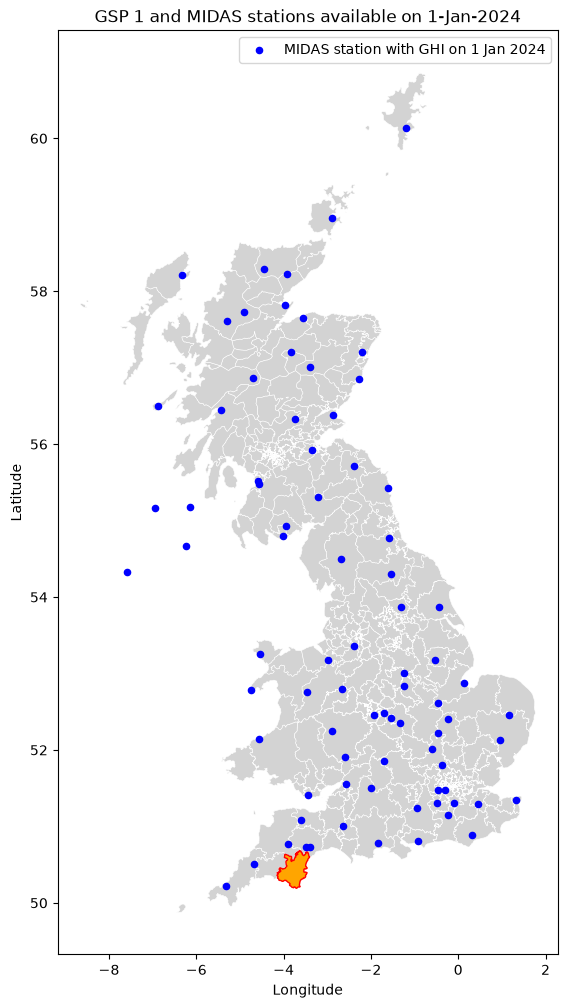

In [259]:
fig, ax = plt.subplots(figsize=(10,12))

gsp_regions.plot(
    ax=ax,
    facecolor='lightgrey',
    edgecolor='white',
    linewidth=0.4,
)

selected_region.plot(
    ax=ax,
    facecolor='orange',
    edgecolor='red',
    linewidth=1
)

midas_points_jan1.plot(
    ax=ax,
    color='blue',
    markersize=20,
    label='MIDAS station with GHI on 1 Jan 2024',
)

ax.set_title('GSP 1 and MIDAS stations available on 1-Jan-2024')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
# plt.show()

Nice. Good showing ^
- Now let's think about the distances

In [260]:
# for meaningful distances, we'll convert from degrees to metres. Brit Nat Grid 27700 is suitable for GB

selected_region_projected = selected_region.to_crs('EPSG:27700') # still looking at that first gsp region (ABHA1)
midas_points_projected = midas_points_jan1.to_crs('EPSG:27700')

In [261]:
# try computing representative point and centroid, compare
gsp_reference_point = selected_region_projected.geometry.representative_point().iloc[0] # similar to centroid but must be in the shape

# let's take a look at where the centroid would put it, too

gsp_centroid_point = selected_region_projected.geometry.centroid.iloc[0] # don't need the () after centroid for some reason; it is a property, whereas rep_point() is a method

In [262]:
type(gsp_reference_point)

shapely.geometry.point.Point

In [263]:
type(gsp_centroid_point)

# So, they're shapely point objects (because extracted via .iloc[0]), not geodataframes. they do not have a .plot() method. should instead use standard matplotlib ax.scatter() to draw the points

shapely.geometry.point.Point

In [264]:
# instead, let's keep them as geodataframes to use native .plot() syntax

repr_series = selected_region_projected.geometry.representative_point()
centr_series = selected_region_projected.geometry.centroid

gsp_reference_point_gdf = gpd.GeoDataFrame(geometry=repr_series, crs=selected_region_projected.crs)
gsp_centroid_point_gdf = gpd.GeoDataFrame(geometry=centr_series, crs=selected_region_projected.crs)

# though for plotting, need to reproject the points to match the main map layer (gsp_regions)
gsp_reference_point_mapped = gsp_reference_point_gdf.to_crs(gsp_regions.crs)
gsp_centroid_point_mapped = gsp_centroid_point_gdf.to_crs(gsp_regions.crs)

In [265]:
type(gsp_reference_point_gdf) # now it's a geodataframe

geopandas.geodataframe.GeoDataFrame

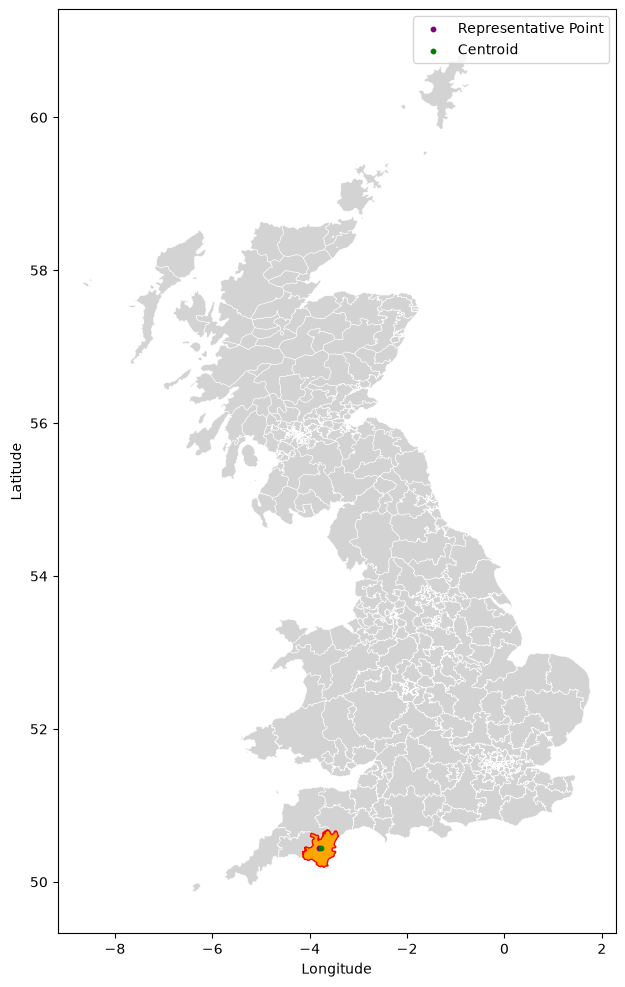

In [266]:
# let's see the difference between centroid and representative pt
fig, ax = plt.subplots(figsize=(10,12))

gsp_regions.plot(
    ax=ax,
    facecolor='lightgrey',
    edgecolor='white',
    linewidth=0.4,
)

selected_region.plot(
    ax=ax,
    facecolor='orange',
    edgecolor='red',
    linewidth=1
)

gsp_reference_point_mapped.plot(
    ax=ax,
    color='purple',
    markersize=10,
    label='Representative Point',
)

gsp_centroid_point_mapped.plot(
    ax=ax,
    color='green',
    markersize=10,
    label='Centroid',
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()

So, very very similar.though it may be much different for cresent-shaped or other weirdly-shaped regions.
- Anyways, back to the task at hand, of inspecting the distances

In [267]:
type(gsp_reference_point) # this one is still shapely, to be used for the metres distance calculations

shapely.geometry.point.Point

In [268]:
# calculate the distance to every MIDAS station

midas_points_projected['distance_km'] = midas_points_projected.geometry.distance(gsp_reference_point)/1000 # natively in metres

In [269]:
# sort by distance

closest_midas = midas_points_projected.sort_values('distance_km')

closest_midas[['station_id', 'distance_km']].head(10) # top 10 closest MIDAS stations to the rep point of the ABHA1 GSP 
# though admittedly they could be much closer to the border of the region or closer to where most of the installed PV is -- we just don't know tbh
# could also consider the location of the gsp's actual substation

# OOOH -- POSSIBLE NEW RESEARCH AREA: could augment the model further by taking into account the location(s) of PV within the GSP regions. Could do some weighted averaging or even involve some unsupervised clustering

,station_id,distance_km
168,01352,37.194748
239,62208,40.234696
236,62041,44.002468
175,01415,60.849753
163,01285,73.489114
164,01302,104.028039
174,01395,110.483964
214,19206,110.580146
108,00842,145.072327
237,62122,151.856313


In [270]:
# now, let's select the closest 3 stations and retrieve their hourly GHI observations

closest_three = closest_midas.head(3)
closest_three[['station_id','distance_km']]

,station_id,distance_km
168,01352,37.194748
239,62208,40.234696
236,62041,44.002468


In [271]:
type(closest_three)

geopandas.geodataframe.GeoDataFrame

In [272]:
closest_three

,station_id,station_latitude,station_longitude,geometry,distance_km
168,01352,50.769,-3.904,POINT (265832.111 98330.364),37.194748
239,62208,50.729,-3.475,POINT (295993.643 93191.317),40.234696
236,62041,50.737,-3.406,POINT (300880.24 93986.061),44.002468


RECALL THAT THIS 'DISTANCE' IS MERELY THEIR DISTANCE TO THE ABHA1 GSP REP_POINT; THEY MAY BE CLOSER TO OTHER GSP REGIONS (and in fact they almost certainly are)

In [273]:
midas_record_lookup = {}

for record in midas_jan1_records:
    midas_record_lookup[record['station_id']] = record
# takes a list of records (midas_jan1_records, which is a list), and converts it to a dictionary, where each key is a station ID and each value is the corresponding record

In [274]:
type(midas_jan1_records) # list
midas_jan1_records

[{'station_id': '00113',
  'station_name': 'aviemore',
  'file_path': PosixPath('../data/inputs/MIDAS202607/inverness-shire/00113_aviemore/qc-version-1/midas-open_uk-radiation-obs_dv-202607_inverness-shire_00113_aviemore_qcv-1_2024.csv'),
  'datetime_column': 'ob_end_time',
  'observations':            ob_end_time id_type      id  ob_hour_count  version_num  \
  0  2024-01-01 00:00:00    DCNN   585.0            1.0          1.0   
  1  2024-01-01 01:00:00    DCNN   585.0            1.0          1.0   
  2  2024-01-01 02:00:00    DCNN   585.0            1.0          1.0   
  3  2024-01-01 03:00:00    DCNN   585.0            1.0          1.0   
  4  2024-01-01 04:00:00    DCNN   585.0            1.0          1.0   
  5  2024-01-01 05:00:00    DCNN   585.0            1.0          1.0   
  6  2024-01-01 06:00:00    DCNN   585.0            1.0          1.0   
  7  2024-01-01 07:00:00    DCNN   585.0            1.0          1.0   
  8  2024-01-01 08:00:00    DCNN   585.0            1.0      

In [275]:
# now combine the closest stations' observations:

closest_midas_hourly = [] # making a list

for station_id in closest_three['station_id']:
    record = midas_record_lookup[station_id]

    station_observations = record['observations'].copy()

    datetime_column = record['datetime_column']

    station_observations = station_observations[[datetime_column, GHI_FIELD]].rename(
        columns = {
            datetime_column: 'datetime_gmt', 
            GHI_FIELD: f'ghi_{station_id}'}
    ) 
    # give each midas station its own title of the form 'ghi_{id here}'

    station_observations['datetime_gmt'] = (
        pd.to_datetime(
            station_observations['datetime_gmt'],
            utc=True,
        )
    )
    # and put it in gmt time (already was -- not sure how daylight savings will act yet)

    closest_midas_hourly.append(
        station_observations.set_index('datetime_gmt')
    )

In [276]:
type(closest_midas_hourly)

list

In [277]:
closest_midas_hourly

[                           ghi_01352
 datetime_gmt                        
 2024-01-01 00:00:00+00:00        0.0
 2024-01-01 01:00:00+00:00        0.0
 2024-01-01 02:00:00+00:00        0.0
 2024-01-01 03:00:00+00:00        0.0
 2024-01-01 04:00:00+00:00        0.0
 2024-01-01 05:00:00+00:00        0.0
 2024-01-01 06:00:00+00:00        0.0
 2024-01-01 07:00:00+00:00        0.0
 2024-01-01 08:00:00+00:00        0.0
 2024-01-01 09:00:00+00:00       29.0
 2024-01-01 10:00:00+00:00      196.0
 2024-01-01 11:00:00+00:00      310.0
 2024-01-01 12:00:00+00:00      421.0
 2024-01-01 13:00:00+00:00      434.0
 2024-01-01 14:00:00+00:00      368.0
 2024-01-01 15:00:00+00:00      121.0
 2024-01-01 16:00:00+00:00       29.0
 2024-01-01 17:00:00+00:00        0.0
 2024-01-01 18:00:00+00:00        0.0
 2024-01-01 19:00:00+00:00        0.0
 2024-01-01 20:00:00+00:00        0.0
 2024-01-01 21:00:00+00:00        0.0
 2024-01-01 22:00:00+00:00        0.0
 2024-01-01 23:00:00+00:00        0.0
 2024-01-01 

In [278]:
# ^ not sure why we'd want it in only one column (though I guess it's a list rn)

closest_midas_hourly = pd.concat(closest_midas_hourly, axis=1).reset_index()

In [279]:
closest_midas_hourly

,datetime_gmt,ghi_01352,ghi_62208,ghi_62041
0,2024-01-01 00:00:00+00:00,0.0,0.0,0.0
1,2024-01-01 01:00:00+00:00,0.0,0.0,0.0
2,2024-01-01 02:00:00+00:00,0.0,0.0,0.0
3,2024-01-01 03:00:00+00:00,0.0,0.0,0.0
4,2024-01-01 04:00:00+00:00,0.0,0.0,0.0
5,2024-01-01 05:00:00+00:00,0.0,0.0,0.0
6,2024-01-01 06:00:00+00:00,0.0,0.0,0.0
7,2024-01-01 07:00:00+00:00,0.0,0.0,0.0
8,2024-01-01 08:00:00+00:00,0.0,0.0,0.0
9,2024-01-01 09:00:00+00:00,29.0,28.0,27.0


In [280]:
# nice, now it is a dataframe with separate columns per station

# NOTE that there is a NaN value in one of the stations. That is a bit worrisome. I'm also not sure why there is a 23:59 value which looks to be a sum; it wouldn't make sense otherwise to have high irradiance values at midnight
type(closest_midas_hourly)

pandas.DataFrame

In [281]:
closest_midas_hourly['ghi_01352'].sum() - closest_midas_hourly['ghi_01352'].iloc[-1]

np.float64(1908.0)

In [282]:
closest_midas_hourly['ghi_01352'].iloc[-1]

np.float64(1909.0)

^ not sure why it disagrees slightly but I guess it is a sum.

In [283]:
closest_midas_hourly['ghi_62041'].sum() - closest_midas_hourly['ghi_62041'].iloc[-1] # this one agrees exactly

np.float64(1664.0)

Note from CSV files:
- long_name,glbl_irad_amt,Global solar irradiation amount,KJ/m2
- type,glbl_irad_amt,int

### Now, let's inspect PVLive columns before plotting together

In [284]:
hourly_data_gsp1.columns.tolist()

['gsp_id', 'datetime_gmt', 'generation_mw']

In [285]:
hourly_data_gsp1.dtypes

gsp_id             int64
datetime_gmt         str
generation_mw    float64
dtype: object

In [286]:
# may need to convert pvlive datetime data to pd datetime:

hourly_data_gsp1['datetime_gmt'] = pd.to_datetime(hourly_data_gsp1['datetime_gmt'], utc=True)

In [287]:
hourly_data_gsp1.dtypes

gsp_id                         int64
datetime_gmt     datetime64[us, UTC]
generation_mw                float64
dtype: object

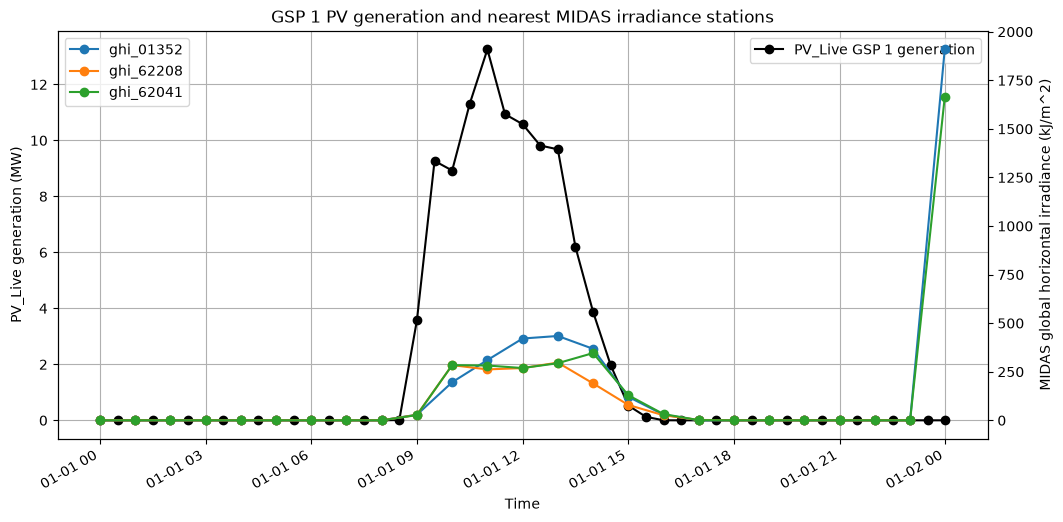

In [288]:
# ^ okay good now it's a datetime datatype in UTC

# Finally, let's plot PVLive and MIDAS together (and inspect that wacky 23:59 stuff from above)
# note:
#   - pvlive generation in MW, half-hourly
#   - MIDAS GHI data in kJ/m^2

fig, ax_pv = plt.subplots(figsize=(12,6))

ax_pv.plot(
    hourly_data_gsp1['datetime_gmt'],
    hourly_data_gsp1['generation_mw'],
    color='black',
    marker='o',
    label='PV_Live GSP 1 generation'
)

ax_pv.set_xlabel('Time') 
ax_pv.set_ylabel('PV_Live generation (MW)')
ax_pv.grid(True)

ax_ghi = ax_pv.twinx()

for column in closest_midas_hourly.columns:
    if column.startswith('ghi_'):
        ax_ghi.plot(
            closest_midas_hourly['datetime_gmt'],
            closest_midas_hourly[column],
            marker='o',
            label=column
        )

ax_ghi.set_ylabel('MIDAS global horizontal irradiance (kJ/m^2)')
ax_pv.set_title('GSP 1 PV generation and nearest MIDAS irradiance stations')
ax_pv.legend()
ax_ghi.legend()

fig.autofmt_xdate()



^ okay good so what can we see:
- GOOD: the GHI are showing up hourly while the PV_Live is half-hourly
- GOOD: I'm getting all the data (I think)
- BAD: at midnight, there is a spike for two of the GHI datasets (might be the sum), and one of the datasets has a NaN in that slot
- MAYBE BAD: why isn't the alignment agreeing; why does PV generation go so high so much earlier than the generation does?

Let's investigate that weird sum row:

In [289]:
record = midas_record_lookup['01352']

record['observations'][['ob_end_time', GHI_FIELD]].tail()

,ob_end_time,glbl_irad_amt
20,2024-01-01 20:00:00,0.0
21,2024-01-01 21:00:00,0.0
22,2024-01-01 22:00:00,0.0
23,2024-01-01 23:00:00,0.0
24,2024-01-01 23:59:00,1909.0


In [290]:
record['observations'].tail(1) # all of the columns for this record. Can do '.T. to transpose to column vector

,ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,glbl_irad_amt,glbl_irad_amt_q,...,direct_irad,direct_irad_q,irad_bal_amt,irad_bal_amt_q,glbl_s_lat_irad_amt,glbl_s_lat_irad_amt_q,glbl_horz_ilmn,glbl_horz_ilmn_q,meto_stmp_time,midas_stmp_etime
24,2024-01-01 23:59:00,DCNN,8836.0,24.0,1.0,AWSHRLY,1352.0,1011.0,1909.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-02 00:03:00,NaN


In [291]:
# where are these midas data coming from exactly:

for station_id in closest_three['station_id']:
    record = midas_record_lookup[station_id]
    print(station_id)
    print(record['station_name'])
    print(record['file_path'])
    print() # blank space

01352
north-wyke
../data/inputs/MIDAS202607/devon/01352_north-wyke/qc-version-1/midas-open_uk-radiation-obs_dv-202607_devon_01352_north-wyke_qcv-1_2024.csv

62208
exeter-surfacenet-enclosure-aws
../data/inputs/MIDAS202607/devon/62208_exeter-surfacenet-enclosure-aws/qc-version-1/midas-open_uk-radiation-obs_dv-202607_devon_62208_exeter-surfacenet-enclosure-aws_qcv-1_2024.csv

62041
exeter-airport-no-2
../data/inputs/MIDAS202607/devon/62041_exeter-airport-no-2/qc-version-1/midas-open_uk-radiation-obs_dv-202607_devon_62041_exeter-airport-no-2_qcv-1_2024.csv



/Users/mans5211/GitHub-repos/Met-Office-Solar-Luke/data/inputs/MIDAS202607/devon/01352_north-wyke/qc-version-1/midas-open_uk-radiation-obs_dv-202607_devon_01352_north-wyke_qcv-1_2024.csv
- Wow so I guess some of these CSV's just silently include daily sums under the 23:59 timestamp. Bizarre.
- So, to compensate for this, I will filter to only timestamps that end in minute 00
    - could  do:
    `station_observations['datetime_gmt'].dt.minute == 0`
    `station_observations["datetime_gmt"].dt.time != pd.Timestamp("23:59:00").time()`
    - to explicitly remove the 23:59 instances...

In [292]:
station_observations = station_observations[
    station_observations["datetime_gmt"].dt.time != pd.Timestamp("23:59:00").time()
].copy()

In [293]:
station_observations

,datetime_gmt,ghi_62041
0,2024-01-01 00:00:00+00:00,0.0
1,2024-01-01 01:00:00+00:00,0.0
2,2024-01-01 02:00:00+00:00,0.0
3,2024-01-01 03:00:00+00:00,0.0
4,2024-01-01 04:00:00+00:00,0.0
5,2024-01-01 05:00:00+00:00,0.0
6,2024-01-01 06:00:00+00:00,0.0
7,2024-01-01 07:00:00+00:00,0.0
8,2024-01-01 08:00:00+00:00,0.0
9,2024-01-01 09:00:00+00:00,27.0


### Corrected time series (summary rows removed):

In [294]:
corrected_midas_hourly_list = []

for station_id in closest_three['station_id']:
    record = midas_record_lookup[station_id]

    station_observations = record['observations'].copy()
    datetime_column = record['datetime_column']

    station_observations = station_observations[
        [datetime_column, GHI_FIELD]
    ].rename(columns = {
        datetime_column: 'datetime_gmt',
        GHI_FIELD: f'ghi_{station_id}',
        }
    )

    station_observations['datetime_gmt'] = pd.to_datetime(
        station_observations['datetime_gmt'],
        utc=True
    )

    # now we remove the daily summary timestamp
    station_observations = station_observations[
        station_observations['datetime_gmt'].dt.strftime('%H:%M') != '23:59'
    ].copy()

    corrected_midas_hourly_list.append(
        station_observations.set_index('datetime_gmt')
    )

In [295]:
# and finally combine in a pd dataframe

corrected_midas_hourly = pd.concat(corrected_midas_hourly_list, axis=1).reset_index()

In [296]:
corrected_midas_hourly

,datetime_gmt,ghi_01352,ghi_62208,ghi_62041
0,2024-01-01 00:00:00+00:00,0.0,0.0,0.0
1,2024-01-01 01:00:00+00:00,0.0,0.0,0.0
2,2024-01-01 02:00:00+00:00,0.0,0.0,0.0
3,2024-01-01 03:00:00+00:00,0.0,0.0,0.0
4,2024-01-01 04:00:00+00:00,0.0,0.0,0.0
5,2024-01-01 05:00:00+00:00,0.0,0.0,0.0
6,2024-01-01 06:00:00+00:00,0.0,0.0,0.0
7,2024-01-01 07:00:00+00:00,0.0,0.0,0.0
8,2024-01-01 08:00:00+00:00,0.0,0.0,0.0
9,2024-01-01 09:00:00+00:00,29.0,28.0,27.0


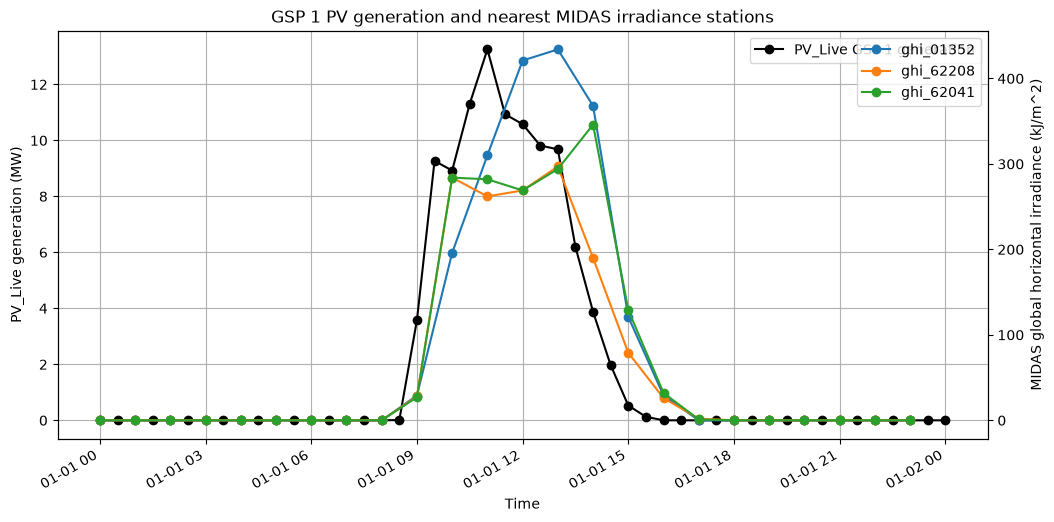

In [297]:
# (borrowed code from above, but using corrected_midas_hourly)

# Finally, let's plot PVLive and MIDAS together (and inspect that wacky 23:59 stuff from above)
# note:
#   - pvlive generation in MW, half-hourly
#   - MIDAS GHI data in kJ/m^2

fig, ax_pv = plt.subplots(figsize=(12,6))

ax_pv.plot(
    hourly_data_gsp1['datetime_gmt'],
    hourly_data_gsp1['generation_mw'],
    color='black',
    marker='o',
    label='PV_Live GSP 1 generation'
)

ax_pv.set_xlabel('Time') 
ax_pv.set_ylabel('PV_Live generation (MW)')
ax_pv.grid(True)

ax_ghi = ax_pv.twinx()

for column in corrected_midas_hourly.columns:
    if column.startswith('ghi_'):
        ax_ghi.plot(
            corrected_midas_hourly['datetime_gmt'],
            corrected_midas_hourly[column],
            marker='o',
            label=column
        )

ax_ghi.set_ylabel('MIDAS global horizontal irradiance (kJ/m^2)')
ax_pv.set_title('GSP 1 PV generation and nearest MIDAS irradiance stations')
ax_pv.legend()
ax_ghi.legend()

fig.autofmt_xdate()



In [298]:
# add W/m^2

# Make a separate copy so the original kJ/m² data remains available.
corrected_midas_hourly_wm2 = (
    corrected_midas_hourly.copy()
)

# Find the MIDAS irradiance columns.
ghi_columns = [
    column
    for column in corrected_midas_hourly_wm2.columns
    if column.startswith("ghi_")
]

# Convert hourly energy from kJ/m² to average power in W/m².
#
# 1 kJ = 1,000 joules
# 1 hour = 3,600 seconds
# Therefore:
# 1 kJ/m² per hour = 1,000 / 3,600 W/m²
#                  = 1 / 3.6 W/m²
for column in ghi_columns:
    corrected_midas_hourly_wm2[column] = (
        corrected_midas_hourly_wm2[column] / 3.6
    )

# Rename the converted columns so their units are obvious.
corrected_midas_hourly_wm2 = (
    corrected_midas_hourly_wm2.rename(
        columns={
            column: f"{column}_wm2"
            for column in ghi_columns
        }
    )
)

# Inspect the converted data.
corrected_midas_hourly_wm2.head(14)

,datetime_gmt,ghi_01352_wm2,ghi_62208_wm2,ghi_62041_wm2
0,2024-01-01 00:00:00+00:00,0.000000,0.000000,0.000000
1,2024-01-01 01:00:00+00:00,0.000000,0.000000,0.000000
2,2024-01-01 02:00:00+00:00,0.000000,0.000000,0.000000
3,2024-01-01 03:00:00+00:00,0.000000,0.000000,0.000000
4,2024-01-01 04:00:00+00:00,0.000000,0.000000,0.000000
5,2024-01-01 05:00:00+00:00,0.000000,0.000000,0.000000
6,2024-01-01 06:00:00+00:00,0.000000,0.000000,0.000000
7,2024-01-01 07:00:00+00:00,0.000000,0.000000,0.000000
8,2024-01-01 08:00:00+00:00,0.000000,0.000000,0.000000
9,2024-01-01 09:00:00+00:00,8.055556,7.777778,7.500000


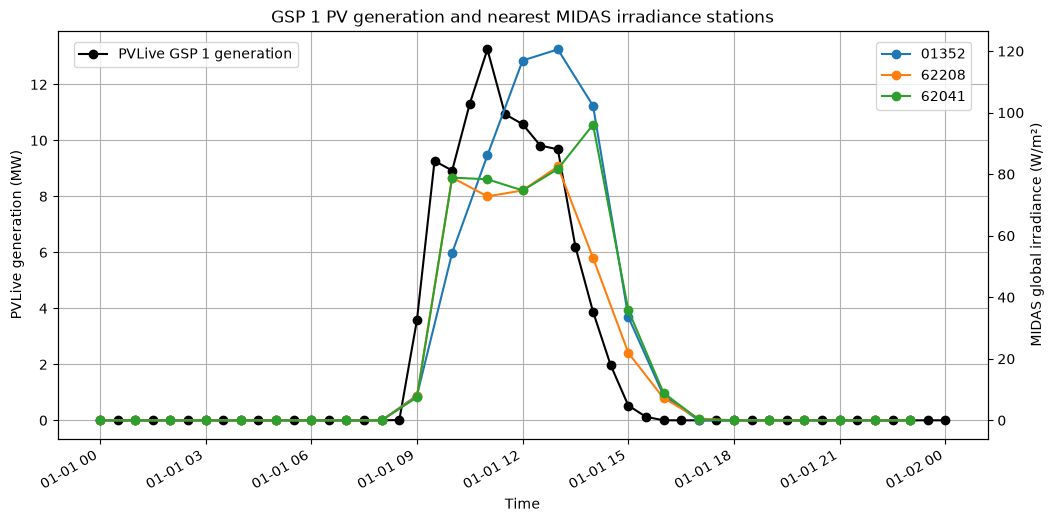

In [299]:
# Create the figure and the left-hand PVLive axis.
fig, ax_pv = plt.subplots(figsize=(12, 6))

# Plot PVLive generation on the left y-axis.
ax_pv.plot(
    hourly_data_gsp1["datetime_gmt"],
    hourly_data_gsp1["generation_mw"],
    color="black",
    marker="o",
    label="PVLive GSP 1 generation",
)

# Label the left-hand axis.
ax_pv.set_xlabel("Time")
ax_pv.set_ylabel("PVLive generation (MW)")
ax_pv.grid(True)

# Create a second y-axis sharing the same time axis.
ax_ghi = ax_pv.twinx()

# Find the converted MIDAS irradiance columns.
wm2_columns = [
    column
    for column in corrected_midas_hourly_wm2.columns
    if column.endswith("_wm2")
]

# Plot each MIDAS station on the right-hand y-axis.
for column in wm2_columns:
    ax_ghi.plot(
        corrected_midas_hourly_wm2["datetime_gmt"],
        corrected_midas_hourly_wm2[column],
        marker="o",
        label=column.replace("ghi_", "").replace("_wm2", ""),
    )

# Label the right-hand axis.
ax_ghi.set_ylabel("MIDAS global irradiance (W/m²)")

# Add a descriptive title.
ax_pv.set_title(
    "GSP 1 PV generation and nearest MIDAS irradiance stations"
)

# Put the two legends in separate corners so they do not overlap.
ax_pv.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
)

ax_ghi.legend(
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
)

# Give the timestamp labels enough room.
fig.autofmt_xdate()

# Display the finished plot.
plt.show()

### Step 4. Do a simple correl with this small sample (GSP 1 with three closest instruments)

- should eventually control for capacity, perhaps by dividing output by nominal capacity (given by PV_Live). though, i'm only considering one GSP so there's no difference
- i guess i should try doing a simple correl with the data I have available here first before looking at the broader dataset
- though I'll have to simplify the pv_live data to just hourly since i don't have half-hourly GHI

In [300]:
# # make an hourly pvlive dataset
# pvlive_hourly = hourly_data_gsp1.copy()

# # use the timestamps as the df index
# pvlive_hourly = pvlive_hourly.set_index('datetime_gmt')

# # convert the half-hourly to hourly AVERAGES
# pvlive_hourly = pvlive_hourly[['generation_mw']].resample('1h').mean()

might be the wrong hourly average... should prob average the 9:30 and the 10:00 to get the 10:00!!!!!!!!!!!!
- so, ignore the above cell
- Corrected version:

In [301]:
hourly_data_gsp1.head(24)

,gsp_id,datetime_gmt,generation_mw
0,1,2024-01-02 00:00:00+00:00,0.000
1,1,2024-01-01 23:30:00+00:00,0.000
2,1,2024-01-01 23:00:00+00:00,0.000
3,1,2024-01-01 22:30:00+00:00,0.000
4,1,2024-01-01 22:00:00+00:00,0.000
5,1,2024-01-01 21:30:00+00:00,0.000
6,1,2024-01-01 21:00:00+00:00,0.000
7,1,2024-01-01 20:30:00+00:00,0.000
8,1,2024-01-01 20:00:00+00:00,0.000
9,1,2024-01-01 19:30:00+00:00,0.000


In [302]:
# e.g. 12:30end is 9.817, 13:00end is 9.680
(9.817 + 9.680)/2 
# this mean should be the new averaged 13:00 time

9.7485

In [303]:
# Make a copy so the original PVLive data remains unchanged.
pvlive_hourly = hourly_data_gsp1.copy()

# Use the period-ending timestamps as the index.
pvlive_hourly = pvlive_hourly.set_index(
    "datetime_gmt"
)

pvlive_hourly = (
    pvlive_hourly[
        ["generation_mw"]
    ]
    .resample(
        "1h",
        closed="right", #   include timestamps at the right-hand edge of each bin.
        label="right", #   label each hourly result with the time at which that period ended
    )
    .mean()
)

# Inspect the resulting timestamps and values.
pvlive_hourly.head(14)

,generation_mw
datetime_gmt,
2024-01-01 00:00:00+00:00,0.0000
2024-01-01 01:00:00+00:00,0.0000
2024-01-01 02:00:00+00:00,0.0000
2024-01-01 03:00:00+00:00,0.0000
2024-01-01 04:00:00+00:00,0.0000
2024-01-01 05:00:00+00:00,0.0000
2024-01-01 06:00:00+00:00,0.0000
2024-01-01 07:00:00+00:00,0.0000
2024-01-01 08:00:00+00:00,0.0000


^ nice, this does in fact agree.
- now let's move on to a simple correlation. I guess the simplest would be to average the three nearest GHI timeseries into one representative one.

In [304]:
pvlive_hourly.index

DatetimeIndex(['2024-01-01 00:00:00+00:00', '2024-01-01 01:00:00+00:00',
               '2024-01-01 02:00:00+00:00', '2024-01-01 03:00:00+00:00',
               '2024-01-01 04:00:00+00:00', '2024-01-01 05:00:00+00:00',
               '2024-01-01 06:00:00+00:00', '2024-01-01 07:00:00+00:00',
               '2024-01-01 08:00:00+00:00', '2024-01-01 09:00:00+00:00',
               '2024-01-01 10:00:00+00:00', '2024-01-01 11:00:00+00:00',
               '2024-01-01 12:00:00+00:00', '2024-01-01 13:00:00+00:00',
               '2024-01-01 14:00:00+00:00', '2024-01-01 15:00:00+00:00',
               '2024-01-01 16:00:00+00:00', '2024-01-01 17:00:00+00:00',
               '2024-01-01 18:00:00+00:00', '2024-01-01 19:00:00+00:00',
               '2024-01-01 20:00:00+00:00', '2024-01-01 21:00:00+00:00',
               '2024-01-01 22:00:00+00:00', '2024-01-01 23:00:00+00:00',
               '2024-01-02 00:00:00+00:00'],
              dtype='datetime64[us, UTC]', name='datetime_gmt', freq='h')

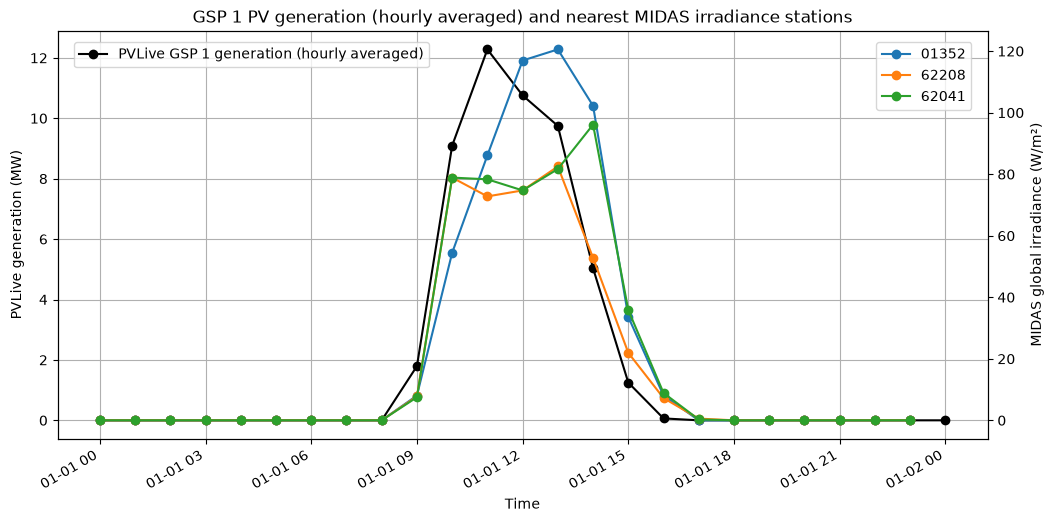

In [305]:
# redoing this plot but with the hourly averaged pv_live data; it smooths out much of the detail of the half-hourly curve unfortunately

# Create the figure and the left-hand PVLive axis.
fig, ax_pv = plt.subplots(figsize=(12, 6))

# Plot PVLive generation on the left y-axis.
ax_pv.plot(
    pvlive_hourly.index, # pvlive_hourly is weird now, need to use its index instead of column datetime_gmt
    pvlive_hourly["generation_mw"],
    color="black",
    marker="o",
    label="PVLive GSP 1 generation (hourly averaged)",
)

# Label the left-hand axis.
ax_pv.set_xlabel("Time")
ax_pv.set_ylabel("PVLive generation (MW)")
ax_pv.grid(True)

# Create a second y-axis sharing the same time axis.
ax_ghi = ax_pv.twinx()

# Find the converted MIDAS irradiance columns.
wm2_columns = [
    column
    for column in corrected_midas_hourly_wm2.columns
    if column.endswith("_wm2")
]

# Plot each MIDAS station on the right-hand y-axis.
for column in wm2_columns:
    ax_ghi.plot(
        corrected_midas_hourly_wm2["datetime_gmt"],
        corrected_midas_hourly_wm2[column],
        marker="o",
        label=column.replace("ghi_", "").replace("_wm2", ""),
    )

# Label the right-hand axis.
ax_ghi.set_ylabel("MIDAS global irradiance (W/m²)")

# Add a descriptive title.
ax_pv.set_title(
    "GSP 1 PV generation (hourly averaged) and nearest MIDAS irradiance stations"
)

# Put the two legends in separate corners so they do not overlap.
ax_pv.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
)

ax_ghi.legend(
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
)

# Give the timestamp labels enough room.
fig.autofmt_xdate()

# Display the finished plot.
plt.show()

-------------  Start of some codex-generated, copy-pasted code, because i'm getting a bit lazy today: -----------------

In [306]:
# Make a copy so the converted MIDAS data remains unchanged.
midas_for_correlation = (
    corrected_midas_hourly_wm2.copy()
)

# Use timestamps as the index.
midas_for_correlation = (
    midas_for_correlation.set_index("datetime_gmt")
)

# Select the converted irradiance columns.
wm2_columns = [
    column
    for column in midas_for_correlation.columns
    if column.endswith("_wm2")
]

# Calculate the average irradiance across the three stations.
midas_for_correlation["mean_ghi_wm2"] = (
    midas_for_correlation[wm2_columns]
    .mean(axis=1)
)

# Keep only the combined irradiance series.
midas_for_correlation = (
    midas_for_correlation[["mean_ghi_wm2"]]
)

# Join PVLive and MIDAS using timestamps that appear in both tables.
comparison_hourly = pvlive_hourly.join(
    midas_for_correlation,
    how="inner",
)

# Remove rows where either measurement is missing.
comparison_hourly = comparison_hourly.dropna(
    subset=[
        "generation_mw",
        "mean_ghi_wm2",
    ]
)

# Inspect the aligned data.
comparison_hourly

,generation_mw,mean_ghi_wm2
datetime_gmt,,
2024-01-01 00:00:00+00:00,0.0000,0.000000
2024-01-01 01:00:00+00:00,0.0000,0.000000
2024-01-01 02:00:00+00:00,0.0000,0.000000
2024-01-01 03:00:00+00:00,0.0000,0.000000
2024-01-01 04:00:00+00:00,0.0000,0.000000
2024-01-01 05:00:00+00:00,0.0000,0.000000
2024-01-01 06:00:00+00:00,0.0000,0.000000
2024-01-01 07:00:00+00:00,0.0000,0.000000
2024-01-01 08:00:00+00:00,0.0000,0.000000


In [307]:
# Calculate Pearson correlation between PV generation
# and average MIDAS irradiance.
correlation = comparison_hourly[
    "generation_mw"
].corr(
    comparison_hourly["mean_ghi_wm2"]
)

print(
    f"Pearson correlation: {correlation:.3f}"
)

Pearson correlation: 0.945


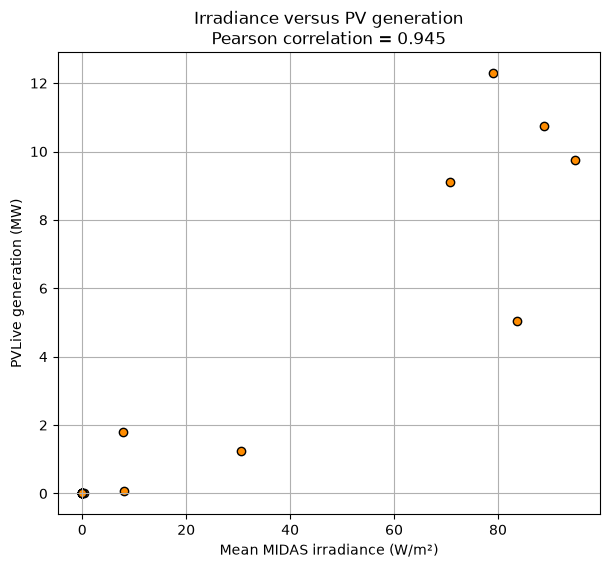

In [308]:
# Create a scatter plot of irradiance against PV generation.
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    comparison_hourly["mean_ghi_wm2"],
    comparison_hourly["generation_mw"],
    color="darkorange",
    edgecolor="black",
)

# Label the axes.
ax.set_xlabel("Mean MIDAS irradiance (W/m²)")
ax.set_ylabel("PVLive generation (MW)")

# Add a title containing the correlation value.
ax.set_title(
    f"Irradiance versus PV generation\n"
    f"Pearson correlation = {correlation:.3f}"
)

# Add a grid to make the values easier to read.
ax.grid(True)

# Display the figure.
plt.show()

^ there simply aren't many (nonzero) points, so it makes sense that the correl would be high

But where are these instruments spatially compared to the GSP?

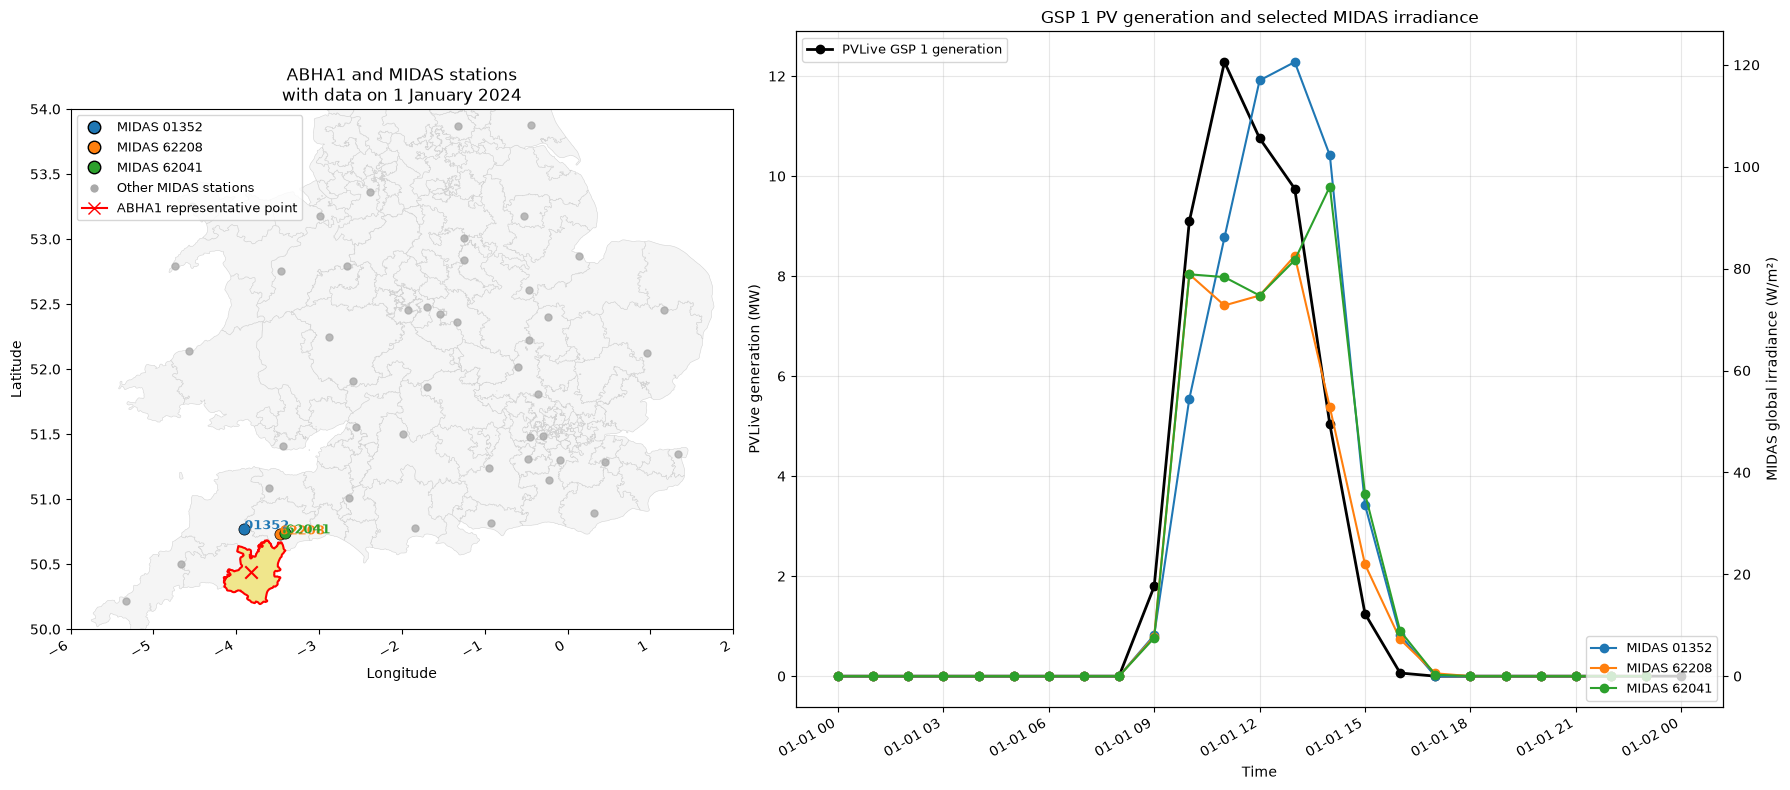

In [309]:
# Import Line2D so we can create a clean map legend manually.
from matplotlib.lines import Line2D

# Create a single figure with two panels:
# the map on the left and the time series on the right.
fig, (ax_map, ax_time) = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    gridspec_kw={"width_ratios": [1, 1.4]},
)

# ---------------------------------------------------------------------
# Identify the selected MIDAS stations
# ---------------------------------------------------------------------

# Convert the selected station IDs to strings for consistent comparison.
selected_station_ids = [
    str(station_id)
    for station_id in closest_three["station_id"]
]

# Give each selected station a colour.
station_colours = {
    station_id: colour
    for station_id, colour in zip(
        selected_station_ids,
        ["tab:blue", "tab:orange", "tab:green"],
    )
}

# ---------------------------------------------------------------------
# Left panel: map
# ---------------------------------------------------------------------

# Plot all GSP regions as a light-grey background.
gsp_regions.plot(
    ax=ax_map,
    facecolor="whitesmoke",
    edgecolor="lightgrey",
    linewidth=0.4,
)

# Highlight ABHA1.
selected_region.plot(
    ax=ax_map,
    facecolor="khaki",
    edgecolor="red",
    linewidth=1.5,
)

# Plot every MIDAS station in dark grey first.
midas_points_jan1.plot(
    ax=ax_map,
    color="darkgrey",
    markersize=25,
    alpha=0.8,
    zorder=3,
)

# Plot the three selected stations again, using their time-series colours.
for station_id, colour in station_colours.items():
    selected_station = midas_points_jan1[
        midas_points_jan1["station_id"].astype(str)
        == station_id
    ]

    selected_station.plot(
        ax=ax_map,
        color=colour,
        edgecolor="black",
        linewidth=0.5,
        markersize=65,
        zorder=4,
    )

# Plot the representative point of the selected GSP.
selected_region.geometry.representative_point().plot(
    ax=ax_map,
    color="red",
    marker="x",
    markersize=80,
    zorder=5,
)

# Label the selected MIDAS stations on the map.
for station_id, colour in station_colours.items():
    selected_station = midas_points_jan1[
        midas_points_jan1["station_id"].astype(str)
        == station_id
    ]

    for _, station_row in selected_station.iterrows():
        ax_map.text(
            station_row.geometry.x,
            station_row.geometry.y,
            station_id,
            fontsize=9,
            color=colour,
            fontweight="bold",
            zorder=6,
        )

# Create map legend entries manually.
map_legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colour,
        markeredgecolor="black",
        markersize=9,
        label=f"MIDAS {station_id}",
    )
    for station_id, colour in station_colours.items()
]

map_legend_handles.extend(
    [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="darkgrey",
            markersize=7,
            label="Other MIDAS stations",
        ),
        Line2D(
            [0],
            [0],
            marker="x",
            color="red",
            markersize=9,
            label="ABHA1 representative point",
        ),
    ]
)

ax_map.legend(
    handles=map_legend_handles,
    loc="upper left",
    fontsize=9,
)

ax_map.set_title(
    "ABHA1 and MIDAS stations\n"
    "with data on 1 January 2024"
)

ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")

# OPTIONAL: Zoom the map to the southern half of Great Britain.
ax_map.set_xlim(-6, 2)
ax_map.set_ylim(50, 54)

# ---------------------------------------------------------------------
# Right panel: time series
# ---------------------------------------------------------------------

# Plot PVLive generation on the left y-axis.
ax_pv = ax_time

ax_pv.plot(
    pvlive_hourly.index,
    pvlive_hourly["generation_mw"],
    color="black",
    marker="o",
    linewidth=2,
    label="PVLive GSP 1 generation",
)

ax_pv.set_xlabel("Time")
ax_pv.set_ylabel("PVLive generation (MW)")
ax_pv.grid(True, alpha=0.3)

# Create a second y-axis for MIDAS irradiance.
ax_ghi = ax_time.twinx()

# Plot each selected MIDAS station using the same colour
# used for its map point.
for station_id, colour in station_colours.items():
    column_name = f"ghi_{station_id}_wm2"

    # Only plot the column if it exists in the converted DataFrame.
    if column_name in corrected_midas_hourly_wm2.columns:
        ax_ghi.plot(
            corrected_midas_hourly_wm2["datetime_gmt"],
            corrected_midas_hourly_wm2[column_name],
            color=colour,
            marker="o",
            linewidth=1.5,
            label=f"MIDAS {station_id}",
        )

ax_ghi.set_ylabel("MIDAS global irradiance (W/m²)")

# Collect the two legends separately so they do not overlap.
pv_handles, pv_labels = ax_pv.get_legend_handles_labels()
ghi_handles, ghi_labels = ax_ghi.get_legend_handles_labels()

# Put the PVLive legend in the upper-left of the time-series panel.
ax_pv.legend(
    pv_handles,
    pv_labels,
    loc="upper left",
    fontsize=9,
)

# Put the MIDAS legend in the lower-right of the time-series panel.
ax_ghi.legend(
    ghi_handles,
    ghi_labels,
    loc="lower right",
    fontsize=9,
)

ax_time.set_title(
    "GSP 1 PV generation and selected MIDAS irradiance"
)

# Rotate date labels so they remain readable.
fig.autofmt_xdate()

# Add space between the map and time-series panels.
fig.tight_layout()


# Display the complete figure.
plt.show()

-----
### Okay, it is now 1st Oct 2026 and I just found those daming results in the AWS live data. I'm now curious if the MIDAS data also has some weird GHI and DNI stuff going on

I guess first I still need to create a reusable global dataset. For now I guess we'll start with the month of Jan 2024, though we may increase this to all of 2024 soon.

In [313]:
import re
from pathlib import Path

import pandas as pd

# Set the inclusive date range you want to analyse.
# These can be changed later, for example to cover all of 2024.
PERIOD_START = "2024-01-01"
PERIOD_END = "2024-12-31"

# MIDAS source fields and their published units.
GHI_FIELD = "glbl_irad_amt"
DNI_FIELD = "direct_irad"
TIME_FIELD = "ob_end_time"
DURATION_FIELD = "ob_hour_count"

# Convert the selected dates into a half-open time interval:
# start date at midnight, up to but not including midnight after the end date.
period_start = pd.Timestamp(PERIOD_START, tz="UTC")
period_end_exclusive = pd.Timestamp(PERIOD_END, tz="UTC") + pd.Timedelta(days=1)

# Find annual MIDAS radiation CSVs whose years overlap the selected period.
# This pattern excludes station-metadata.csv.
candidate_files = []

for file_path in MIDAS_DATA_PATH.glob(
    "**/midas-open_uk-radiation-obs_*_????.csv"
):
    # Get the year from the end of the filename, such as "..._2024.csv".
    year_match = re.search(r"_(\d{4})\.csv$", file_path.name)
    if year_match is None:
        continue

    file_year = int(year_match.group(1))

    # Only consider files for years that overlap the requested date range.
    if period_start.year <= file_year <= period_end_exclusive.year:
        candidate_files.append(file_path)

print(f"Annual radiation files found for the selected years: {len(candidate_files)}")

# For each station and year, keep the file from the highest QC-version folder.
best_file_by_station_year = {}

for file_path in candidate_files:
    # The station folder is two levels above the CSV:
    # station folder / qc-version folder / CSV file.
    station_folder = file_path.parent.parent.name

    # Read the year from the filename.
    file_year = int(re.search(r"_(\d{4})\.csv$", file_path.name).group(1))

    # Read the QC version number from a folder such as "qc-version-1".
    qc_folder = file_path.parent.name
    qc_match = re.fullmatch(r"qc-version-(\d+)", qc_folder)

    # Skip files whose folder does not identify a QC version.
    if qc_match is None:
        continue

    qc_version = int(qc_match.group(1))
    station_year_key = (station_folder, file_year)

    # Replace the saved file only if this one has a higher QC version.
    current_choice = best_file_by_station_year.get(station_year_key)
    if current_choice is None or qc_version > current_choice[0]:
        best_file_by_station_year[station_year_key] = (qc_version, file_path)

selected_files = [
    file_info[1]
    for file_info in best_file_by_station_year.values()
]

print(f"Station-year files selected after QC-version choice: {len(selected_files)}")

# Read one MIDAS CSV, skipping its descriptive preamble before the real header.
def read_midas_radiation_file(file_path):
    # Find the row that contains the observation-table header.
    header_row = None

    with file_path.open("r", encoding="utf-8-sig") as file:
        for row_number, line in enumerate(file):
            columns_in_line = line.strip().split(",")

            # The observation table starts with ob_ fields and has at least
            # one of the two radiation variables we want to study.
            has_observation_fields = any(
                column.startswith("ob_") for column in columns_in_line
            )
            has_radiation_field = (
                GHI_FIELD in columns_in_line or DNI_FIELD in columns_in_line
            )

            if has_observation_fields and has_radiation_field:
                header_row = row_number
                break

    # If no suitable observation table exists, skip this file.
    if header_row is None:
        return None

    # Read the full table, retaining all original data columns.
    return pd.read_csv(file_path, skiprows=header_row)

# Read, date-filter, and collect station data.
station_period_parts = []
files_read = 0
files_with_period_data = 0
files_without_radiation_fields = 0

for file_number, file_path in enumerate(selected_files, start=1):
    station_data = read_midas_radiation_file(file_path)

    # Skip files without a recognizable observation table.
    if station_data is None or TIME_FIELD not in station_data.columns:
        files_without_radiation_fields += 1
        continue

    files_read += 1

    # Convert the timestamp field to UTC datetimes for filtering.
    station_data[TIME_FIELD] = pd.to_datetime(
        station_data[TIME_FIELD],
        errors="coerce",
        utc=True,
    )

    # Convert the two irradiation measurements to numeric values.
    # Keep every other source column as it appeared in the file.
    for field in [GHI_FIELD, DNI_FIELD]:
        if field in station_data.columns:
            station_data[field] = pd.to_numeric(
                station_data[field],
                errors="coerce",
            )

    # Keep only observations whose end time falls within the selected dates.
    in_period = (
        (station_data[TIME_FIELD] >= period_start)
        & (station_data[TIME_FIELD] < period_end_exclusive)
    )
    station_data = station_data.loc[in_period].copy()

    # A station qualifies if it has at least one non-missing GHI or DNI value
    # during the requested period.
    ghi_available = (
        station_data[GHI_FIELD].notna()
        if GHI_FIELD in station_data.columns
        else pd.Series(False, index=station_data.index)
    )
    dni_available = (
        station_data[DNI_FIELD].notna()
        if DNI_FIELD in station_data.columns
        else pd.Series(False, index=station_data.index)
    )

    station_data = station_data.loc[ghi_available | dni_available].copy()

    # Skip this station file if neither measurement has data in the period.
    if station_data.empty:
        continue

    files_with_period_data += 1

    # Add station and provenance columns so rows remain identifiable after combining.
    station_folder = file_path.parent.parent.name
    station_data["station_folder"] = station_folder
    station_data["station_id"] = station_folder.split("_", 1)[0]
    station_data["source_qc_version"] = file_path.parent.name
    station_data["source_file"] = str(file_path)

    # Make sure duration is numeric if it exists in this file.
    if DURATION_FIELD in station_data.columns:
        station_data[DURATION_FIELD] = pd.to_numeric(
            station_data[DURATION_FIELD],
            errors="coerce",
        )
        interval_hours = station_data[DURATION_FIELD]
    else:
        # Without a duration, we cannot safely convert an accumulated amount
        # into average power, so the derived W/m² fields will be missing.
        interval_hours = pd.Series(
            float("nan"),
            index=station_data.index,
        )

    # Mark 23:59 timestamps explicitly instead of silently deleting them.
    station_data["is_23_59_timestamp"] = (
        station_data[TIME_FIELD].dt.strftime("%H:%M") == "23:59"
    )

    # A row reporting 24 observation hours is a daily-length accumulation.
    # Keep it, but flag it so it is not confused with a single-hour value.
    station_data["is_24_hour_summary"] = interval_hours >= 23

    # Describe the record type using its timestamp and reported duration.
    station_data["record_type"] = "other or unknown duration"
    station_data.loc[
        (interval_hours >= 23)
        & station_data["is_23_59_timestamp"],
        "record_type",
    ] = "24-hour summary at 23:59"
    station_data.loc[
        (interval_hours == 1)
        & (station_data[TIME_FIELD].dt.minute == 0),
        "record_type",
    ] = "one-hour observation"

    # Convert accumulated kJ/m² into average W/m² over the stated interval:
    # W/m² = (kJ/m² × 1000 J/kJ) / (duration in hours × 3600 seconds/hour).
    # This is equivalent to dividing kJ/m² by 3.6 × duration_hours.
    if GHI_FIELD in station_data.columns:
        station_data["glbl_irad_amt_wm2"] = (
            station_data[GHI_FIELD] / (3.6 * interval_hours)
        )

    if DNI_FIELD in station_data.columns:
        station_data["direct_irad_wm2"] = (
            station_data[DNI_FIELD] / (3.6 * interval_hours)
        )

    # Keep this station's rows for the combined dataset.
    station_period_parts.append(station_data)

    # Print occasional progress during the local file scan.
    if file_number % 25 == 0:
        print(f"Checked {file_number} of {len(selected_files)} files")

# Combine the station tables, allowing for columns that exist only in some files.
if station_period_parts:
    midas_radiation_period = pd.concat(
        station_period_parts,
        ignore_index=True,
        sort=False,
    )

    # Sort by station and observation end time for easier inspection.
    midas_radiation_period = midas_radiation_period.sort_values(
        ["station_id", TIME_FIELD]
    ).reset_index(drop=True)
else:
    midas_radiation_period = pd.DataFrame()
    print("No GHI or DNI observations were found in the selected period.")

# Summarize what was loaded and how 23:59 rows were classified.
print(f"\nRequested period: {PERIOD_START} through {PERIOD_END}, inclusive")
print(f"Files with observations in this period: {files_with_period_data}")
print(f"Distinct stations with GHI or DNI: "
      f"{midas_radiation_period['station_id'].nunique() if not midas_radiation_period.empty else 0}")

if not midas_radiation_period.empty:
    print("\nRecord types:")
    print(midas_radiation_period["record_type"].value_counts().to_string())

    print("\n23:59 records (kept and flagged):")
    print(int(midas_radiation_period["is_23_59_timestamp"].sum()))

    print("\nStations with values in each key field:")
    for field in [GHI_FIELD, DNI_FIELD]:
        if field in midas_radiation_period.columns:
            stations_with_values = (
                midas_radiation_period.loc[
                    midas_radiation_period[field].notna(),
                    "station_id",
                ]
                .nunique()
            )
            print(f"  {field}: {stations_with_values}")

    # Show per-station record counts and available measurement counts.
    station_summary = (
        midas_radiation_period
        .groupby(["station_id", "station_folder"], dropna=False)
        .agg(
            rows=(TIME_FIELD, "size"),
            ghi_values=(GHI_FIELD, "count") if GHI_FIELD in midas_radiation_period.columns
            else (TIME_FIELD, "size"),
            dni_values=(DNI_FIELD, "count") if DNI_FIELD in midas_radiation_period.columns
            else (TIME_FIELD, "size"),
            daily_summaries=("is_24_hour_summary", "sum"),
        )
        .reset_index()
    )

    display(station_summary.head(20))

Annual radiation files found for the selected years: 322
Station-year files selected after QC-version choice: 161
Checked 75 of 161 files
Checked 100 of 161 files

Requested period: 2024-01-01 through 2024-12-31, inclusive
Files with observations in this period: 80
Distinct stations with GHI or DNI: 80

Record types:
record_type
one-hour observation        695169
24-hour summary at 23:59     28769

23:59 records (kept and flagged):
28769

Stations with values in each key field:
  glbl_irad_amt: 80
  direct_irad: 0


,station_id,station_folder,rows,ghi_values,dni_values,daily_summaries
0,00009,00009_lerwick,9101,9101,0,365
1,00023,00023_kirkwall,9102,9102,0,366
2,00044,00044_altnaharra-no-2,9146,9146,0,366
3,00048,00048_kinbrace-hatchery,9143,9143,0,362
4,00054,00054_stornoway-airport,9148,9148,0,365
5,00066,00066_kinlochewe,8836,8836,0,355
6,00067,00067_loch-glascarnoch,9108,9108,0,364
7,00079,00079_tain-range,9125,9125,0,365
8,00105,00105_tulloch-bridge,9097,9097,0,366
9,00113,00113_aviemore,9114,9114,0,365


Uh oh. None of the stations have direct irad? Let's check the other irrad parameters.

In [315]:
import re
from pathlib import Path

import pandas as pd

# Set the inclusive date range to load.
# Change these two dates to use another period.
PERIOD_START = "2024-01-01"
PERIOD_END = "2024-12-31"

# MIDAS timestamp and observation-duration fields.
TIME_FIELD = "ob_end_time"
DURATION_FIELD = "ob_hour_count"

# Radiation-related values to retain and check.
# MIDAS documents these amounts in kJ/m².
RADIATION_FIELDS = [
    "glbl_irad_amt",       # Global irradiation (GHI)
    "direct_irad",         # Direct irradiation (DNI-related field)
    "difu_irad_amt",       # Diffuse irradiation
    "irad_bal_amt",        # Irradiation balance
    "glbl_s_lat_irad_amt", # Global south-latitude irradiation
    "glbl_horz_ilmn",      # Global horizontal illumination
]

# Convert the requested dates to UTC boundaries.
# The end boundary is exclusive, so the full end date is included.
period_start = pd.Timestamp(PERIOD_START, tz="UTC")
period_end_exclusive = (
    pd.Timestamp(PERIOD_END, tz="UTC") + pd.Timedelta(days=1)
)

# Find annual radiation files whose years overlap the selected date range.
# This filename pattern excludes station-metadata.csv.
candidate_files = []

for file_path in MIDAS_DATA_PATH.glob(
    "**/midas-open_uk-radiation-obs_*_????.csv"
):
    # The annual data year appears at the end of the filename.
    year_match = re.search(r"_(\d{4})\.csv$", file_path.name)
    if year_match is None:
        continue

    file_year = int(year_match.group(1))

    # Skip files from years outside the requested range.
    if period_start.year <= file_year <= pd.Timestamp(PERIOD_END).year:
        candidate_files.append(file_path)

print(f"Annual radiation files found: {len(candidate_files)}")

# Choose the highest QC-version file for each station and year.
best_file_by_station_year = {}

for file_path in candidate_files:
    # The station folder is two levels above the CSV file.
    station_folder = file_path.parent.parent.name

    # Extract the year from the filename.
    file_year = int(re.search(r"_(\d{4})\.csv$", file_path.name).group(1))

    # Read the QC version from a folder such as "qc-version-1".
    qc_match = re.fullmatch(r"qc-version-(\d+)", file_path.parent.name)
    if qc_match is None:
        continue

    qc_version = int(qc_match.group(1))
    station_year = (station_folder, file_year)

    # Keep this file if it's the first for the station-year,
    # or if its QC version is higher than the saved choice.
    saved_choice = best_file_by_station_year.get(station_year)
    if saved_choice is None or qc_version > saved_choice[0]:
        best_file_by_station_year[station_year] = (qc_version, file_path)

selected_files = [
    saved_choice[1]
    for saved_choice in best_file_by_station_year.values()
]

print(f"Station-year files selected: {len(selected_files)}")

# Read a MIDAS observation table, skipping the descriptive text at the top.
def read_midas_radiation_file(file_path):
    # Find the line where the actual observation-table header begins.
    header_row = None

    with file_path.open("r", encoding="utf-8-sig") as file:
        for row_number, line in enumerate(file):
            columns = line.strip().split(",")

            # A valid table header has observation fields and at least
            # one of the radiation columns we want to inspect.
            has_observation_fields = any(
                column.startswith("ob_") for column in columns
            )
            has_radiation_fields = any(
                field in columns for field in RADIATION_FIELDS
            )

            if has_observation_fields and has_radiation_fields:
                header_row = row_number
                break

    # Return None if this file doesn't contain a matching table.
    if header_row is None:
        return None

    # Read every source column, including QC columns.
    return pd.read_csv(file_path, skiprows=header_row)

# Read files, retain rows in the date range, and keep rows with
# at least one available radiation measurement.
period_parts = []

for file_number, file_path in enumerate(selected_files, start=1):
    station_data = read_midas_radiation_file(file_path)

    # Skip files without a usable observation table or timestamp field.
    if station_data is None or TIME_FIELD not in station_data.columns:
        continue

    # Parse the observation-end timestamps as UTC.
    station_data[TIME_FIELD] = pd.to_datetime(
        station_data[TIME_FIELD],
        errors="coerce",
        utc=True,
    )

    # Convert the available radiation columns to numeric values.
    fields_in_file = [
        field for field in RADIATION_FIELDS
        if field in station_data.columns
    ]
    for field in fields_in_file:
        station_data[field] = pd.to_numeric(
            station_data[field],
            errors="coerce",
        )

    # Keep observations whose end times fall within the selected dates.
    in_period = (
        (station_data[TIME_FIELD] >= period_start)
        & (station_data[TIME_FIELD] < period_end_exclusive)
    )
    station_data = station_data.loc[in_period].copy()

    # Keep a row if at least one of the radiation measurements is present.
    if not fields_in_file or station_data.empty:
        continue

    has_any_radiation = station_data[fields_in_file].notna().any(axis=1)
    station_data = station_data.loc[has_any_radiation].copy()

    if station_data.empty:
        continue

    # Add station and source-file information to identify each row.
    station_folder = file_path.parent.parent.name
    station_data["station_folder"] = station_folder
    station_data["station_id"] = station_folder.split("_", 1)[0]
    station_data["source_qc_version"] = file_path.parent.name
    station_data["source_file"] = str(file_path)

    # Read the observation duration in hours.
    if DURATION_FIELD in station_data.columns:
        station_data[DURATION_FIELD] = pd.to_numeric(
            station_data[DURATION_FIELD],
            errors="coerce",
        )
        interval_hours = station_data[DURATION_FIELD]
    else:
        # If the duration is missing, the W/m² conversion can't be calculated.
        interval_hours = pd.Series(float("nan"), index=station_data.index)

    # Mark 23:59 rows so they can be distinguished from ordinary hourly rows.
    station_data["is_23_59_timestamp"] = (
        station_data[TIME_FIELD].dt.strftime("%H:%M") == "23:59"
    )

    # A 23:59 record covering about 24 hours is a daily summary.
    station_data["is_24_hour_summary"] = (
        station_data["is_23_59_timestamp"]
        & (interval_hours >= 23)
    )

    # Mark regular hourly observations separately.
    station_data["is_native_hourly_observation"] = (
        (interval_hours == 1)
        & (station_data[TIME_FIELD].dt.minute == 0)
        & ~station_data["is_24_hour_summary"]
    )

    # Label the type of record for easy inspection.
    station_data["record_type"] = "other interval or unknown"
    station_data.loc[
        station_data["is_native_hourly_observation"],
        "record_type",
    ] = "native hourly observation"
    station_data.loc[
        station_data["is_24_hour_summary"],
        "record_type",
    ] = "24-hour summary at 23:59"

    # Convert each kJ/m² accumulation to average W/m² over its own interval:
    # kJ/m² × 1000 J/kJ, divided by interval duration in seconds.
    for field in fields_in_file:
        output_field = f"{field}_wm2"
        station_data[output_field] = (
            station_data[field] / (3.6 * interval_hours)
        )

    # Keep all rows with any of the radiation measurements.
    period_parts.append(station_data)

    # Print progress occasionally during the local file scan.
    if file_number % 25 == 0:
        print(f"Checked {file_number} of {len(selected_files)} files")

# Combine all station data while retaining the source fields.
if period_parts:
    midas_radiation_period_all = pd.concat(
        period_parts,
        ignore_index=True,
        sort=False,
    )
    midas_radiation_period_all = midas_radiation_period_all.sort_values(
        ["station_id", TIME_FIELD]
    ).reset_index(drop=True)
else:
    midas_radiation_period_all = pd.DataFrame()
    print("No radiation measurements found in this date range.")

# Keep native hourly observations in the main time-series dataset.
if not midas_radiation_period_all.empty:
    midas_radiation_hourly = midas_radiation_period_all[
        midas_radiation_period_all["is_native_hourly_observation"]
    ].copy()

    # Keep full-day 23:59 summaries separate rather than mixing them
    # into the hourly time series.
    midas_daily_summaries = midas_radiation_period_all[
        midas_radiation_period_all["is_24_hour_summary"]
    ].copy()

    # Keep any remaining unusual-duration records available for review.
    midas_other_interval_rows = midas_radiation_period_all[
        ~midas_radiation_period_all["is_native_hourly_observation"]
        & ~midas_radiation_period_all["is_24_hour_summary"]
    ].copy()

    print(f"\nRequested period: {PERIOD_START} through {PERIOD_END}")
    print(
        "Stations with any radiation data in the period:",
        midas_radiation_period_all["station_id"].nunique(),
    )
    print(
        "Native hourly observation rows:",
        len(midas_radiation_hourly),
    )
    print(
        "24-hour summaries separated out:",
        len(midas_daily_summaries),
    )
    print(
        "Other-interval rows kept separately:",
        len(midas_other_interval_rows),
    )

    # Count stations with values in each radiation field,
    # using native hourly observations only.
    print("\nStations with native hourly values in each field:")
    for field in RADIATION_FIELDS:
        if field in midas_radiation_hourly.columns:
            station_count = midas_radiation_hourly.loc[
                midas_radiation_hourly[field].notna(),
                "station_id",
            ].nunique()
            value_count = midas_radiation_hourly[field].notna().sum()
            print(
                f"  {field}: {station_count} stations, "
                f"{value_count} observations"
            )

    # Build a station-by-station summary of hourly measurements.
    station_summary = (
        midas_radiation_hourly
        .groupby(["station_id", "station_folder"])
        .size()
        .rename("native_hourly_rows")
        .to_frame()
    )

    for field in RADIATION_FIELDS:
        if field in midas_radiation_hourly.columns:
            station_summary[f"{field}_count"] = (
                midas_radiation_hourly
                .groupby(["station_id", "station_folder"])[field]
                .count()
            )

    station_summary = station_summary.reset_index()
    display(station_summary.head(25))

Annual radiation files found: 160
Station-year files selected: 80
Checked 25 of 80 files
Checked 50 of 80 files
Checked 75 of 80 files

Requested period: 2024-01-01 through 2024-12-31
Stations with any radiation data in the period: 80
Native hourly observation rows: 695169
24-hour summaries separated out: 28769
Other-interval rows kept separately: 0

Stations with native hourly values in each field:
  glbl_irad_amt: 80 stations, 695169 observations
  direct_irad: 0 stations, 0 observations
  difu_irad_amt: 0 stations, 0 observations
  irad_bal_amt: 0 stations, 0 observations
  glbl_s_lat_irad_amt: 0 stations, 0 observations
  glbl_horz_ilmn: 0 stations, 0 observations


,station_id,station_folder,native_hourly_rows,glbl_irad_amt_count,direct_irad_count,difu_irad_amt_count,irad_bal_amt_count,glbl_s_lat_irad_amt_count,glbl_horz_ilmn_count
0,00009,00009_lerwick,8736,8736,0,0,0,0,0
1,00023,00023_kirkwall,8736,8736,0,0,0,0,0
2,00044,00044_altnaharra-no-2,8780,8780,0,0,0,0,0
3,00048,00048_kinbrace-hatchery,8781,8781,0,0,0,0,0
4,00054,00054_stornoway-airport,8783,8783,0,0,0,0,0
5,00066,00066_kinlochewe,8481,8481,0,0,0,0,0
6,00067,00067_loch-glascarnoch,8744,8744,0,0,0,0,0
7,00079,00079_tain-range,8760,8760,0,0,0,0,0
8,00105,00105_tulloch-bridge,8731,8731,0,0,0,0,0
9,00113,00113_aviemore,8749,8749,0,0,0,0,0


I don't know why they bother to have those other irrad parameters in the top row if none of the stations even offer that data! Anyways, let's take a look at some of this GHI time series data at least
- Then, we'll inspect longer time series, and compare to GSP output

In [317]:
station_data

,ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,glbl_irad_amt,glbl_irad_amt_q,...,is_23_59_timestamp,is_24_hour_summary,is_native_hourly_observation,record_type,glbl_irad_amt_wm2,direct_irad_wm2,difu_irad_amt_wm2,irad_bal_amt_wm2,glbl_s_lat_irad_amt_wm2,glbl_horz_ilmn_wm2
0,2024-01-01 00:00:00+00:00,DCNN,3357.0,1.0,1.0,AWSHRLY,456.0,1011.0,0.0,6.0,...,False,False,True,native hourly observation,0.000000,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00+00:00,DCNN,3357.0,1.0,1.0,AWSHRLY,456.0,1011.0,0.0,6.0,...,False,False,True,native hourly observation,0.000000,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00+00:00,DCNN,3357.0,1.0,1.0,AWSHRLY,456.0,1011.0,0.0,6.0,...,False,False,True,native hourly observation,0.000000,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00+00:00,DCNN,3357.0,1.0,1.0,AWSHRLY,456.0,1011.0,0.0,6.0,...,False,False,True,native hourly observation,0.000000,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 04:00:00+00:00,DCNN,3357.0,1.0,1.0,AWSHRLY,456.0,1011.0,0.0,6.0,...,False,False,True,native hourly observation,0.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9145,2024-12-31 20:00:00+00:00,DCNN,3357.0,1.0,1.0,AWSHRLY,456.0,1011.0,0.0,6.0,...,False,False,True,native hourly observation,0.000000,NaN,NaN,NaN,NaN,NaN
9146,2024-12-31 21:00:00+00:00,DCNN,3357.0,1.0,1.0,AWSHRLY,456.0,1011.0,0.0,6.0,...,False,False,True,native hourly observation,0.000000,NaN,NaN,NaN,NaN,NaN
9147,2024-12-31 22:00:00+00:00,DCNN,3357.0,1.0,1.0,AWSHRLY,456.0,1011.0,0.0,6.0,...,False,False,True,native hourly observation,0.000000,NaN,NaN,NaN,NaN,NaN
9148,2024-12-31 23:00:00+00:00,DCNN,3357.0,1.0,1.0,AWSHRLY,456.0,1011.0,0.0,6.0,...,False,False,True,native hourly observation,0.000000,NaN,NaN,NaN,NaN,NaN


Plot period: 2024-01-01 through 2024-01-07, inclusive
Stations with GHI in this period: 79
Pages of 5 stations: 16

Stations on page 1:
  00009 — 00009_lerwick
  00023 — 00023_kirkwall
  00044 — 00044_altnaharra-no-2
  00048 — 00048_kinbrace-hatchery
  00054 — 00054_stornoway-airport


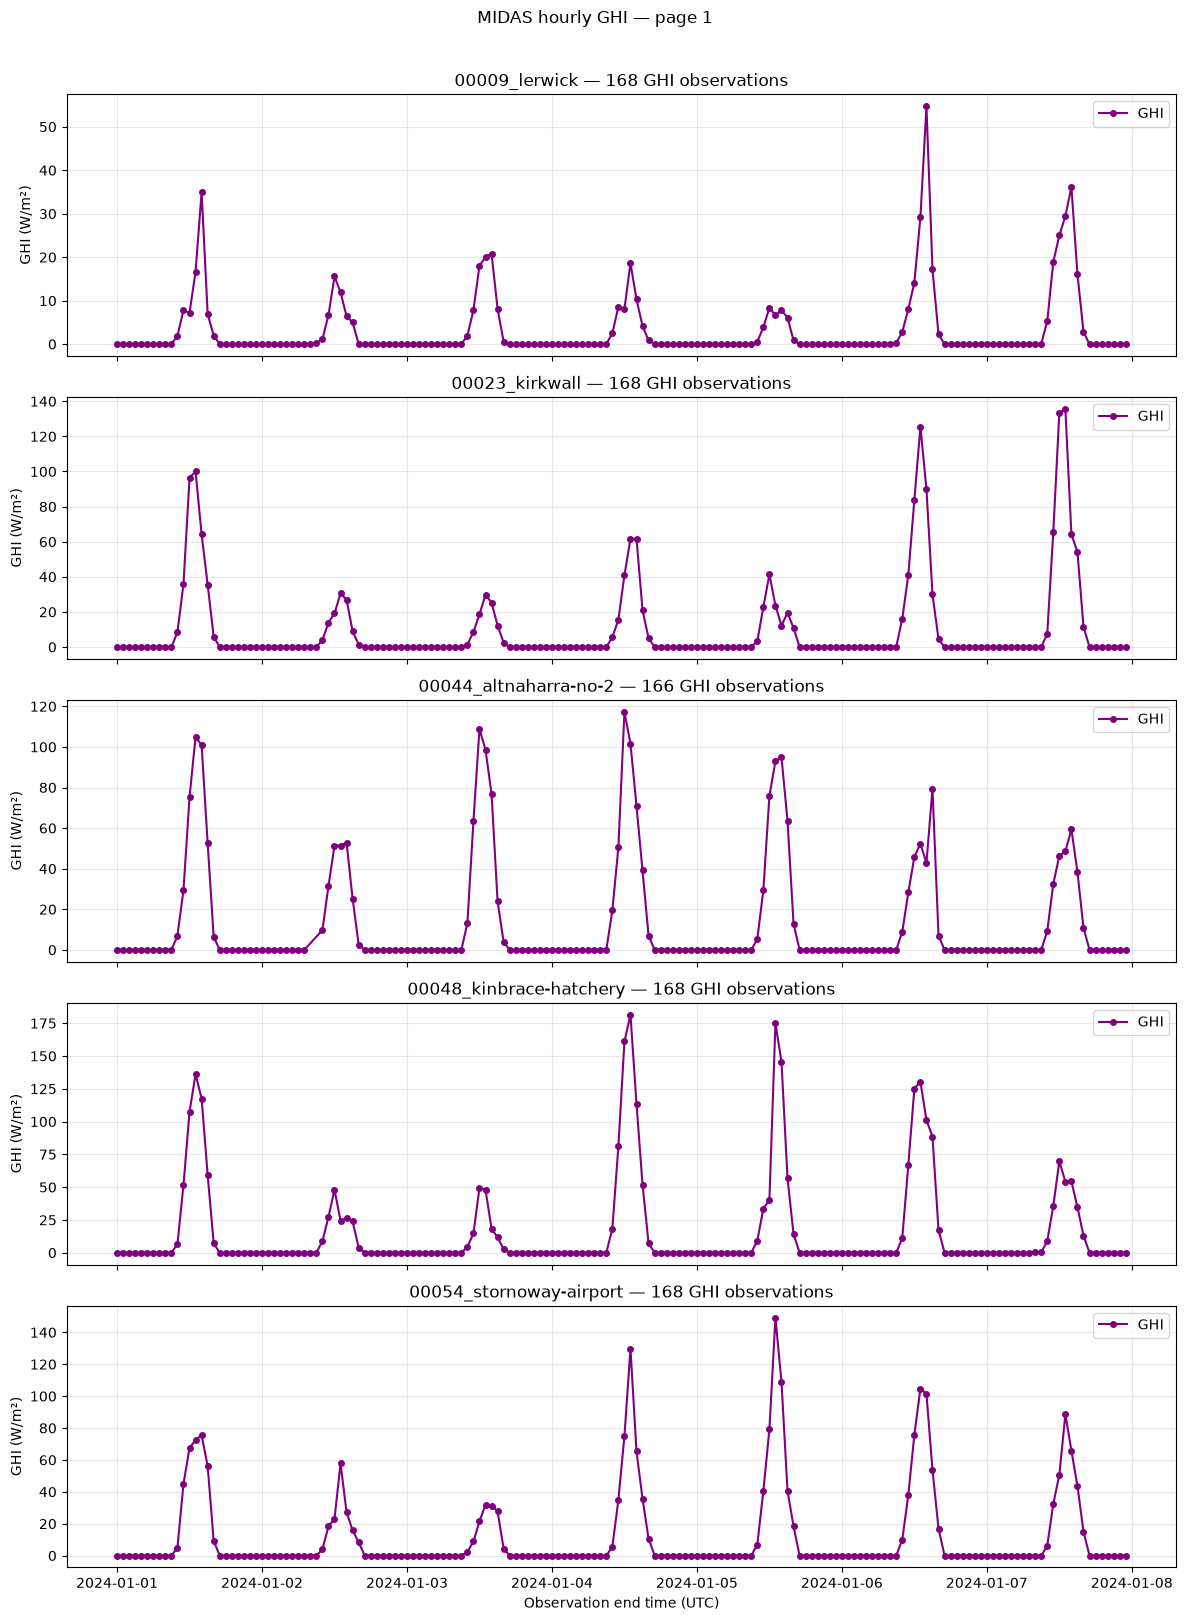

In [319]:
import pandas as pd
import matplotlib.pyplot as plt

# Choose the inclusive date range to plot.
PLOT_START = "2024-01-01"
PLOT_END = "2024-01-07"
# The plot dates must fall within the range loaded by the previous dataset-building cell. For just Jan 1, 2024, set both dates below to "2024-01-01".

# Change this to view a different page of five stations.
# Page 1 shows stations 1–5; page 2 shows stations 6–10, and so on.
page_number = 1

# Set the number of stations shown on each page.
stations_per_page = 5

# The previous dataset-building cell should have created this DataFrame.
# It contains native hourly observations, with daily summaries kept separate.
if "midas_radiation_hourly" not in globals():
    raise NameError(
        "Run the MIDAS dataset-building cell first to create "
        "'midas_radiation_hourly'."
    )

# Confirm the columns needed for this plot exist.
required_columns = [
    "station_id",
    "station_folder",
    "ob_end_time",
    "glbl_irad_amt",
    "glbl_irad_amt_wm2",
]
missing_columns = [
    column
    for column in required_columns
    if column not in midas_radiation_hourly.columns
]
if missing_columns:
    raise KeyError(
        f"Required columns are missing from midas_radiation_hourly: "
        f"{missing_columns}"
    )

# Convert the selected dates into UTC boundaries.
plot_start = pd.Timestamp(PLOT_START, tz="UTC")
plot_end_exclusive = (
    pd.Timestamp(PLOT_END, tz="UTC") + pd.Timedelta(days=1)
)

# Work on a copy so this plotting cell does not change the main dataset.
plot_data = midas_radiation_hourly.copy()

# Make sure timestamps are datetime values in UTC.
plot_data["ob_end_time"] = pd.to_datetime(
    plot_data["ob_end_time"],
    utc=True,
    errors="coerce",
)

# Keep only observations within the chosen date range.
plot_data = plot_data[
    (plot_data["ob_end_time"] >= plot_start)
    & (plot_data["ob_end_time"] < plot_end_exclusive)
].copy()

# Keep stations that actually have GHI values during this plotted period.
stations_with_ghi = (
    plot_data.loc[plot_data["glbl_irad_amt"].notna(),
                  ["station_id", "station_folder"]]
    .drop_duplicates()
    .sort_values("station_folder")
    .reset_index(drop=True)
)

# Calculate how many pages are needed for all stations with GHI.
station_count = len(stations_with_ghi)
total_pages = (station_count + stations_per_page - 1) // stations_per_page

print(f"Plot period: {PLOT_START} through {PLOT_END}, inclusive")
print(f"Stations with GHI in this period: {station_count}")
print(f"Pages of {stations_per_page} stations: {total_pages}")

# Check that the requested page is valid.
if station_count == 0:
    raise ValueError("No stations with GHI values were found in this period.")

if page_number < 1 or page_number > total_pages:
    raise ValueError(f"Choose a page number from 1 to {total_pages}.")

# Select this page's five stations.
first_index = (page_number - 1) * stations_per_page
last_index = first_index + stations_per_page
page_stations = stations_with_ghi.iloc[first_index:last_index]

print(f"\nStations on page {page_number}:")
for _, station in page_stations.iterrows():
    print(f"  {station['station_id']} — {station['station_folder']}")

# Make one time-series plot for each station on this page.
fig, axes = plt.subplots(
    nrows=len(page_stations),
    ncols=1,
    figsize=(12, 3.2 * len(page_stations)),
    sharex=True,
    squeeze=False,
)
axes = axes[:, 0]

for ax, (_, station) in zip(axes, page_stations.iterrows()):
    # Select this station's rows and put them in time order.
    station_data = plot_data[
        plot_data["station_id"].astype(str)
        == str(station["station_id"])
    ].sort_values("ob_end_time")

    # Plot hourly-average GHI in purple.
    ax.plot(
        station_data["ob_end_time"],
        station_data["glbl_irad_amt_wm2"],
        color="purple",
        marker="o",
        markersize=4,
        label="GHI",
    )

    # Include the number of observations in the station title.
    ax.set_title(
        f"{station['station_folder']} — "
        f"{station_data['glbl_irad_amt_wm2'].notna().sum()} GHI observations"
    )
    ax.set_ylabel("GHI (W/m²)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

# Label the shared time axis and show the page number.
axes[-1].set_xlabel("Observation end time (UTC)")
fig.suptitle(f"MIDAS hourly GHI — page {page_number}", y=1.01)
fig.tight_layout()
plt.show()

In [350]:
# Quick math for met office data quantity
recordsEstimate = 10 * 87 * 48*2 * 365
#           years, stations, rec/day, days/year
# for rec/day, 48 would be half-hourly, so 48*2 would be 15-minutely
print(recordsEstimate)


30484800


In [351]:
recordsEstimate/1000000

30.4848

15-minutely That would be 30.5 million records. Depending on the number of byte per record (I think 1char=1byte), then let's say 150 chars:

In [352]:
recordsEstimate_size_bytes = recordsEstimate*150 # 150 is the number of bytes (estimated) per record
print(recordsEstimate_size_bytes)



4572720000


In [353]:
recordsEstimate_size_GB = recordsEstimate_size_bytes/(10e9)
print(recordsEstimate_size_GB)

0.457272


In [355]:
87*10*365.25*96

30505680.0

### Step 5. Try more advanced models with multiple instruments, based explicitly or implicitly on proximity

- do we have global dataset for 2024 to run analyses on? (MIDAS)
- how about of pvlive gsp data? may need to pull that still

In [356]:
midas_radiation_period

,ob_end_time,id_type,id,ob_hour_count,version_num,met_domain_name,src_id,rec_st_ind,glbl_irad_amt,glbl_irad_amt_q,...,midas_stmp_etime,station_folder,station_id,source_qc_version,source_file,is_23_59_timestamp,is_24_hour_summary,record_type,glbl_irad_amt_wm2,direct_irad_wm2
0,2024-01-01 00:00:00+00:00,DCNN,44.0,1.0,1.0,HCM,9.0,1011.0,0.0,6.0,...,0.0,00009_lerwick,00009,qc-version-1,../data/inputs/MIDAS202607/shetland/00009_lerw...,False,False,one-hour observation,0.000000,NaN
1,2024-01-01 01:00:00+00:00,DCNN,44.0,1.0,1.0,HCM,9.0,1011.0,0.0,6.0,...,0.0,00009_lerwick,00009,qc-version-1,../data/inputs/MIDAS202607/shetland/00009_lerw...,False,False,one-hour observation,0.000000,NaN
2,2024-01-01 02:00:00+00:00,DCNN,44.0,1.0,1.0,HCM,9.0,1011.0,0.0,6.0,...,0.0,00009_lerwick,00009,qc-version-1,../data/inputs/MIDAS202607/shetland/00009_lerw...,False,False,one-hour observation,0.000000,NaN
3,2024-01-01 03:00:00+00:00,DCNN,44.0,1.0,1.0,HCM,9.0,1011.0,0.0,6.0,...,0.0,00009_lerwick,00009,qc-version-1,../data/inputs/MIDAS202607/shetland/00009_lerw...,False,False,one-hour observation,0.000000,NaN
4,2024-01-01 04:00:00+00:00,DCNN,44.0,1.0,1.0,HCM,9.0,1011.0,0.0,6.0,...,0.0,00009_lerwick,00009,qc-version-1,../data/inputs/MIDAS202607/shetland/00009_lerw...,False,False,one-hour observation,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723933,2024-11-11 07:00:00+00:00,WMO,3800.0,1.0,1.0,SYNOP,62208.0,1011.0,0.0,6.0,...,170.0,62208_exeter-surfacenet-enclosure-aws,62208,qc-version-1,../data/inputs/MIDAS202607/devon/62208_exeter-...,False,False,one-hour observation,0.000000,NaN
723934,2024-11-11 08:00:00+00:00,WMO,3800.0,1.0,1.0,SYNOP,62208.0,1011.0,9.0,6.0,...,110.0,62208_exeter-surfacenet-enclosure-aws,62208,qc-version-1,../data/inputs/MIDAS202607/devon/62208_exeter-...,False,False,one-hour observation,2.500000,NaN
723935,2024-11-11 09:00:00+00:00,WMO,3800.0,1.0,1.0,SYNOP,62208.0,1011.0,236.0,6.0,...,50.0,62208_exeter-surfacenet-enclosure-aws,62208,qc-version-1,../data/inputs/MIDAS202607/devon/62208_exeter-...,False,False,one-hour observation,65.555556,NaN
723936,2024-11-11 10:00:00+00:00,WMO,3800.0,1.0,1.0,SYNOP,62208.0,1011.0,463.0,6.0,...,899.0,62208_exeter-surfacenet-enclosure-aws,62208,qc-version-1,../data/inputs/MIDAS202607/devon/62208_exeter-...,False,False,one-hour observation,128.611111,NaN


In [357]:
type(midas_radiation_period)

pandas.DataFrame

Let's save one canonical MIDAS dataset for 2024:
- hourly csv is the clean native hourly observation rows; excludes daily summary rows (23:59)
best for time eries analysis. Preferrred for stats and modelling probably. analysis ready
- all rows csv: contains all raw stuff

In [ ]:
from pathlib import Path

output_dir = Path("../data/outputs/MIDAS202607")
output_dir.mkdir(parents=True, exist_ok=True)

hourly_path = output_dir / "midas_2024_hourly_radiation.csv" # this file is massive (>200 MB), needs to be gitignored
period_path = output_dir / "midas_2024_all_rows_radiation.csv" # this file is massive (>200 MB), needs to be gitignored

# Save the main analysis table: native hourly rows only
midas_radiation_hourly.to_csv(hourly_path, index=False)

# Optional: save every row in the selected period, including summaries
midas_radiation_period.to_csv(period_path, index=False)

print(f"Saved hourly MIDAS data to: {hourly_path}")
print(f"Saved full-period MIDAS data to: {period_path}")

Saved hourly MIDAS data to: ../data/outputs/MIDAS202607/midas_2024_hourly_radiation.csv
Saved full-period MIDAS data to: ../data/outputs/MIDAS202607/midas_2024_all_rows_radiation.csv


I want to now do some correl analysis on the MIDAS data (whatever we have; i think this is just GHI but maybe we have some DNI data too?) versus GSP pv-outturn.
- Check if there is indeed any MIDAS DNI data?
    - If not, just keep on moving with the GHI data
- Need to create global dataset of GSP PV-outturn
- Match up the irrad (prob DNI) data to GSP
    - to start with, just by nearest point
- Start with a simple scatter of irrad versus nearest GSP PV-outturn (divided by ('normalised by') capacity)
    - will need to aggregate the half-hourly pv data to hourly
    - see what the correlation is like
    - see what the correlation is like when increasing the latency;

- Note; but based on the way recent timeseries info actually gets put into the quartz model, it isn’t necessarily about correlations; it’s about whether the model can find some pattern about what’s happening and try to predict the future based on lots of data!


## 2024 DNI check and nearest-GSP PV comparison

This section answers two practical questions for the GB 2024 analysis:

1. Does the MIDAS archive include a usable DNI field in the selected 2024 export?
2. Can we compare 2024 GHI observations to normalised PV output from the nearest GSP region?

The answer for the first question is: the archive includes a direct-irradiance field, but in this 2024 hourly export it is entirely null. So there is no usable DNI series in the saved 2024 MIDAS table for this project.

direct_irad: non-null=0 share=0.0%
direct_irad_wm2: non-null=0 share=0.0%
difu_irad_amt: non-null=0 share=0.0%
difu_irad_amt_wm2: non-null=0 share=0.0%

Native hourly rows in 2024 MIDAS dataset: 695,169
GHI non-null rows: 695,169
count    695169.000000
mean        109.366623
std         182.563309
min           0.000000
25%           0.000000
50%           4.722222
75%         147.500000
max        1046.944444
Name: glbl_irad_amt_wm2, dtype: float64


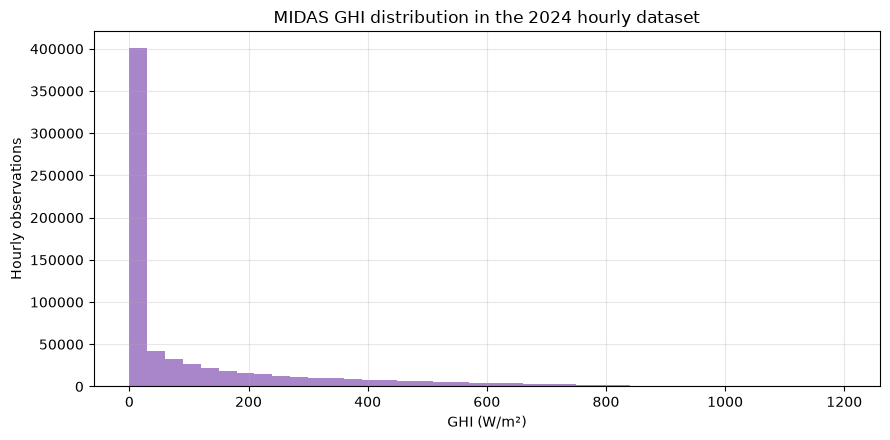

In [361]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

MIDAS_2024_PATH = Path("../data/outputs/MIDAS202607/midas_2024_hourly_radiation.csv")

midas_2024 = pd.read_csv(MIDAS_2024_PATH)
midas_2024["ob_end_time"] = pd.to_datetime(
    midas_2024["ob_end_time"],
    utc=True,
    errors="coerce",
)

# Keep only native hourly observations; ignore daily-summary rows such as 23:59.
midas_2024 = midas_2024[
    midas_2024["is_native_hourly_observation"].fillna(False)
].copy()

# These are the direct-irradiance columns in the MIDAS archive. In the saved 2024
# hourly export, they are all null, so there is no usable DNI series here.
for column in ["direct_irad", "direct_irad_wm2", "difu_irad_amt", "difu_irad_amt_wm2"]:
    series = midas_2024[column]
    print(f"{column}: non-null={series.notna().sum():,} share={series.notna().mean():.1%}")

print(f"\nNative hourly rows in 2024 MIDAS dataset: {len(midas_2024):,}")
print(f"GHI non-null rows: {midas_2024['glbl_irad_amt_wm2'].notna().sum():,}")
print(midas_2024["glbl_irad_amt_wm2"].describe())

# This illustrates the actually available solar signal in the 2024 MIDAS file:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(
    midas_2024["glbl_irad_amt_wm2"].dropna(),
    bins=40,
    range=(0, 1200),
    color="tab:purple",
    alpha=0.8,
)
ax.set_title("MIDAS GHI distribution in the 2024 hourly dataset")
ax.set_xlabel("GHI (W/m²)")
ax.set_ylabel("Hourly observations")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Build 2024 PVLive GSP dataset for GB

The PVLive API returns hourly generation for each GSP. We save a compact 2024 table with the columns needed for the scatter plot and then normalise generation by GSP capacity.

This is the cleanest way to compare weather and generation on a common hourly time axis without re-querying the API every time.

In [ ]:
from pathlib import Path
import time

import pandas as pd
import requests

API_BASE_URL = "https://api.pvlive.uk/pvlive/api/v4"
PVLIVE_2024_PATH = Path("../data/outputs/reference_data/pvlive_2024_gsp_hourly.csv") # this file is massive (>200 MB), needs to be gitignored
PVLIVE_2024_PATH.parent.mkdir(parents=True, exist_ok=True)


def get_pvlive_table(endpoint, params=None):
    response = requests.get(
        f"{API_BASE_URL}/{endpoint}",
        params=params,
        timeout=60,
    )
    response.raise_for_status()
    payload = response.json()
    return pd.DataFrame(payload.get("data", []), columns=payload.get("meta", []))


if PVLIVE_2024_PATH.exists():
    pvlive_2024_gsp = pd.read_csv(PVLIVE_2024_PATH)
    pvlive_2024_gsp["datetime_gmt"] = pd.to_datetime(
        pvlive_2024_gsp["datetime_gmt"],
        utc=True,
        errors="coerce",
    )
else:
    gsp_lookup = get_pvlive_table("gsp_list")
    gsp_lookup = gsp_lookup[gsp_lookup["gsp_id"] != 0].copy()
    gsp_lookup["gsp_id"] = gsp_lookup["gsp_id"].astype(int)

    records = []
    failed_ids = []

    for gsp_id in gsp_lookup["gsp_id"]:
        try:
            df = get_pvlive_table(
                f"gsp/{int(gsp_id)}",
                params={
                    "start": "2024-01-01T00:00:00",
                    "end": "2024-12-31T23:00:00",
                    "extra_fields": "capacity_mwp",
                },
            )
            if df.empty:
                continue

            # Keep only the columns needed for the comparison; generation_mw and
            # capacity_mwp are the key values for this analysis.
            df = df[["datetime_gmt", "generation_mw", "capacity_mwp"]].copy()
            df["gsp_id"] = int(gsp_id)
            df["datetime_gmt"] = pd.to_datetime(df["datetime_gmt"], utc=True, errors="coerce")
            df["generation_mw"] = pd.to_numeric(df["generation_mw"], errors="coerce")
            df["capacity_mwp"] = pd.to_numeric(df["capacity_mwp"], errors="coerce")
            records.append(df)
        except requests.RequestException as error:
            failed_ids.append({"gsp_id": int(gsp_id), "error": str(error)})
        time.sleep(0.05)

    if not records:
        raise RuntimeError("No PVLive 2024 GSP records were downloaded.")

    pvlive_2024_gsp = pd.concat(records, ignore_index=True)
    pvlive_2024_gsp = pvlive_2024_gsp.dropna(
        subset=["datetime_gmt", "generation_mw", "capacity_mwp"]
    ).copy()

    # Normalise generation by capacity to get a fraction of installed output.
    # This makes direct comparisons with irradiance more interpretable than raw MW.
    pvlive_2024_gsp["generation_normalised"] = (
        pvlive_2024_gsp["generation_mw"] / pvlive_2024_gsp["capacity_mwp"]
    )

    pvlive_2024_gsp.to_csv(PVLIVE_2024_PATH, index=False)

print(f"Rows in 2024 PVLive GSP table: {len(pvlive_2024_gsp):,}")
print(f"GSPs represented: {pvlive_2024_gsp['gsp_id'].nunique()}")
print(pvlive_2024_gsp.head().to_string(index=False))

Rows in 2024 PVLive GSP table: 5,866,240
GSPs represented: 334
             datetime_gmt  generation_mw  capacity_mwp  gsp_id  generation_normalised
2024-12-31 23:00:00+00:00            0.0       195.203       1                    0.0
2024-12-31 22:30:00+00:00            0.0       195.203       1                    0.0
2024-12-31 22:00:00+00:00            0.0       195.203       1                    0.0
2024-12-31 21:30:00+00:00            0.0       195.203       1                    0.0
2024-12-31 21:00:00+00:00            0.0       195.203       1                    0.0


### Scatter: 2024 GHI vs nearest-GSP PV output (normalised)

The key idea is to match each MIDAS station to the nearest GSP polygon, then align the hourly GHI observation to the corresponding GSP's hourly output fraction.

This keeps the geometry and time alignment explicit and makes the plotting step straightforward.

Rows in final scatter table: 138,007
 glbl_irad_amt_wm2  generation_normalised
               0.0                    0.0
               0.0                    0.0
               0.0                    0.0
               0.0                    0.0
               0.0                    0.0


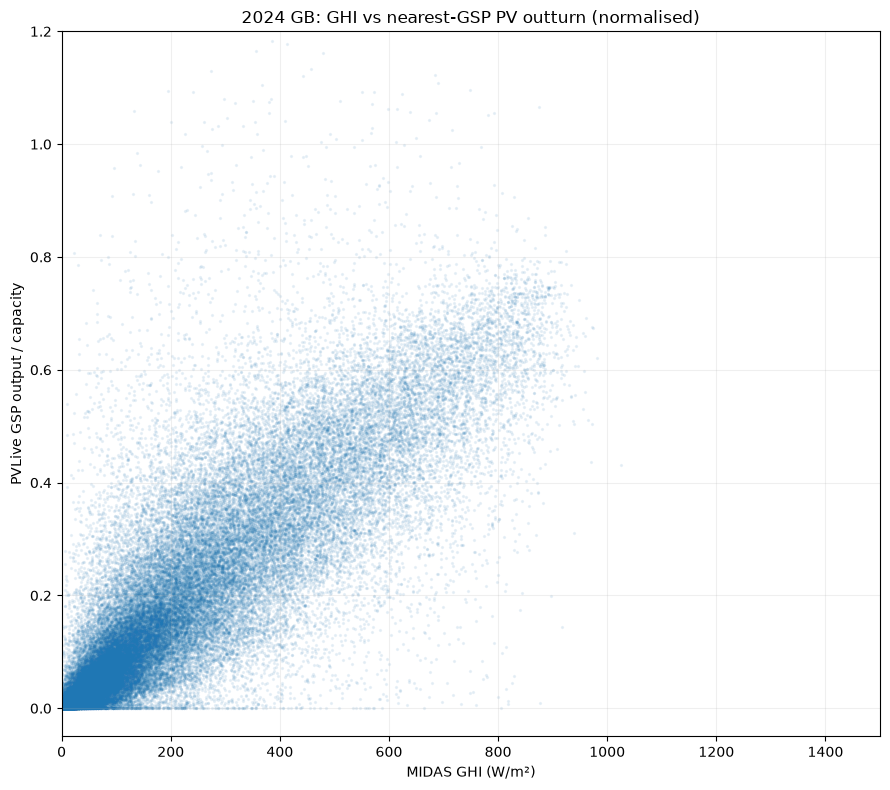

In [363]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Station metadata comes from the MIDAS archive and gives latitude/longitude.
station_metadata_path = Path("../data/inputs/MIDAS202607/station-metadata.csv")

with station_metadata_path.open("r") as fh:
    lines = fh.readlines()

header_row = next(i for i, line in enumerate(lines) if line.startswith("src_id,"))
station_metadata = pd.read_csv(station_metadata_path, skiprows=header_row)
station_metadata = station_metadata[
    ["src_id", "station_name", "station_latitude", "station_longitude"]
].drop_duplicates().copy()
station_metadata = station_metadata.rename(columns={"src_id": "station_id"})
station_metadata["station_id"] = station_metadata["station_id"].astype(str)

station_points = gpd.GeoDataFrame(
    station_metadata,
    geometry=gpd.points_from_xy(
        station_metadata["station_longitude"],
        station_metadata["station_latitude"],
    ),
    crs="EPSG:4326",
).to_crs("EPSG:27700")

# The GSP polygons already carry the GB region IDs and their geometry.
gsp_regions = gpd.read_file(
    "../data/outputs/reference_data/gsp_regions_with_pvlive_capacity.geojson"
).to_crs("EPSG:27700")

nearest_station_gsp = gpd.sjoin_nearest(
    station_points[["station_id", "station_name", "geometry"]],
    gsp_regions[["gsp_id", "gsp_name", "geometry"]],
    how="left",
    distance_col="distance_m",
)
nearest_station_gsp = nearest_station_gsp[
    ["station_id", "gsp_id", "gsp_name", "distance_m"]
].copy()

# Keep only native hourly GHI values and merge with the nearest-GSP assignment.
ghi_hourly = midas_2024[
    midas_2024["glbl_irad_amt_wm2"].notna()
][["ob_end_time", "station_id", "glbl_irad_amt_wm2"]].copy()
ghi_hourly["station_id"] = ghi_hourly["station_id"].astype(str)

joined = ghi_hourly.merge(
    nearest_station_gsp,
    on="station_id",
    how="left",
)

# Match the hourly GHI records with the corresponding GSP PV-Live generation fraction.
# The GHI data are in W/m²; the PV data are converted to a normalised fraction of capacity.
scatter_df = joined.merge(
    pvlive_2024_gsp[["gsp_id", "datetime_gmt", "generation_normalised"]],
    left_on=["gsp_id", "ob_end_time"],
    right_on=["gsp_id", "datetime_gmt"],
    how="inner",
).drop(columns=["datetime_gmt"])

scatter_df = scatter_df[
    ["glbl_irad_amt_wm2", "generation_normalised"]
].dropna().copy()

# Keep the physically sensible range for the plot and drop obvious merge anomalies.
scatter_df = scatter_df[
    scatter_df["glbl_irad_amt_wm2"].between(0, 1500)
    & scatter_df["generation_normalised"].between(-0.05, 1.5)
]

print(f"Rows in final scatter table: {len(scatter_df):,}")
print(scatter_df.head().to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(
    scatter_df["glbl_irad_amt_wm2"],
    scatter_df["generation_normalised"],
    s=2,
    alpha=0.08,
    color="tab:blue",
)
ax.set_xlabel("MIDAS GHI (W/m²)")
ax.set_ylabel("PVLive GSP output / capacity")
ax.set_title("2024 GB: GHI vs nearest-GSP PV outturn (normalised)")
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 1500)
ax.set_ylim(-0.05, 1.2)
plt.tight_layout()
plt.show()

^ Beautiful scatter plot!

Also for the outputs:
- remote: error: File data/outputs/reference_data/pvlive_2024_gsp_hourly.csv is 296.84 MB; this exceeds GitHub's file size limit of 100.00 MB        
- remote: error: File data/outputs/MIDAS202607/midas_2024_hourly_radiation.csv is 237.42 MB; this exceeds GitHub's file size limit of 100.00 MB        
- remote: error: File data/outputs/MIDAS202607/midas_2024_all_rows_radiation.csv is 237.85 MB; this exceeds GitHub's file size limit of 100.00 MB 